# Resource Selection Function

## 0. Set-Up

* Load packages
* Get Dask to run
* Get ee to run on each worker

In [1]:
import geemap, ee
import pandas as pd, geopandas as gpd
import xarray
import hvplot, hvplot.pandas, hvplot.xarray
import matplotlib.pyplot as plt, seaborn as sns
import numpy as np
import xarray as xr
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from scipy.stats import spearmanr
import itertools
import skgstat as skg
from shapely import Polygon, Point
import rioxarray as rio
ee.Initialize(project = "test-with-greta")

In [2]:
from dask.distributed import default_client
try:
    default_client().shutdown()
except Exception:
    pass

In [3]:
from dask.distributed import Client, LocalCluster
import os, dask

cluster = LocalCluster(
    n_workers=max(2, os.cpu_count()//2),
    threads_per_worker=1,
    processes=True,
    memory_limit="auto",
    dashboard_address=":8787",
    local_directory=r"dask-tmp",
)

dask.config.set({
    "distributed.worker.memory.target": 0.75,
    "distributed.worker.memory.spill": 0.85,
    "distributed.worker.memory.pause": 0.92,
    "distributed.worker.memory.terminate": 0.98,
})

def init_ee():
    import ee
    ee.Initialize(project = "test-with-greta")
    ee.data.setCloudApiUserProject("test-with-greta")
    return ee.Number(1).getInfo()

client = Client(cluster)
client.run(init_ee)

{'tcp://127.0.0.1:33115': 1,
 'tcp://127.0.0.1:33323': 1,
 'tcp://127.0.0.1:34115': 1,
 'tcp://127.0.0.1:35679': 1,
 'tcp://127.0.0.1:39521': 1,
 'tcp://127.0.0.1:39611': 1,
 'tcp://127.0.0.1:42533': 1,
 'tcp://127.0.0.1:42555': 1,
 'tcp://127.0.0.1:42677': 1,
 'tcp://127.0.0.1:45451': 1,
 'tcp://127.0.0.1:46483': 1,
 'tcp://127.0.0.1:46515': 1}

## 1. Preparation

* Transform relocation data into geodataframe
* Get the layer from ee to sample from

### 1.1 Presence data

#### 1.1.1 Single Individual

In [ ]:
reloc = pd.read_csv("data/ost009.csv")[["Individual_ID", "Timestamp", "Latitude", "Longitude"]]
reloc = gpd.GeoDataFrame(reloc, geometry = gpd.points_from_xy(reloc["Longitude"], reloc["Latitude"]), crs = 4326)
reloc = reloc.to_crs("epsg:32733")
reloc["Timestamp"] = pd.to_datetime(reloc["Timestamp"])
reloc.head()

In [ ]:
reloc.to_crs(4326).hvplot(geo = True, width = 800, height = 600, tiles = "OSM", title = "Relocations observed")

#### 1.1.2 Multiple Individuals

In [4]:
all = pd.read_csv("data/influx_data_all_2024-07-15-2026-04-02.csv", low_memory=False)

In [5]:
# Subset to pangolin
all_pangolins = all[all["Species"] == "Pangolin"] 
all_pangolins = all_pangolins[["Individual_ID", "Timestamp", "Latitude", "Longitude"]]
all_pangolins["Timestamp"] = pd.to_datetime(all_pangolins["Timestamp"])

In [6]:
# Subset to valid points
gps_points = all_pangolins.dropna(subset = ["Latitude", "Longitude"])
gps_points = gps_points[((gps_points["Latitude"] != 0) & (gps_points["Longitude"] != 0))]
gps_points = gpd.GeoDataFrame(gps_points, geometry = gpd.points_from_xy(gps_points["Longitude"], gps_points["Latitude"]), crs = 4326)
gps_points = gps_points.to_crs("epsg:32733")

In [7]:
# Subset to points within perimeter
perimeter = gpd.read_file("shapefiles/OKJ_Okonjima_Nature_Reserve.shp", engine = "pyogrio")
perimeter = Polygon(perimeter.geometry.iloc[0])
perimeter = gpd.GeoDataFrame({"ID": ["perimeter"]}, geometry = [perimeter], crs = 4326).to_crs(32733)
buffered_perimeter = perimeter.geometry.buffer(10_000)
aoi = gpd.GeoDataFrame(geometry = buffered_perimeter, crs = 32733)
reloc = gps_points[gps_points.geometry.within(buffered_perimeter.geometry.union_all())]

In [8]:
# Remove points around Sven's house
africat = Point(16.64602802460817, -20.852922284953834)
africat = gpd.GeoSeries(africat, crs = 4326).to_crs(32733)
africat_buffer = africat.buffer(1000)
reloc = reloc[~reloc.geometry.within(africat_buffer.geometry.iloc[0])]

In [9]:
# Remove points around Airfield
airfield = Point(16.637302, -20.861337)
airfield = gpd.GeoSeries(airfield, crs = 4326).to_crs(32733)
airfield_buffer = airfield.buffer(100)
reloc = reloc[~reloc.geometry.within(airfield_buffer.geometry.iloc[0])]

In [10]:
# Remove points around B1
b1 = Point(16.800148, -20.846528)
b1 = gpd.GeoSeries(b1, crs = 4326).to_crs(32733)
b1_buffer = b1.buffer(100)
reloc = reloc[~reloc.geometry.within(b1.geometry.iloc[0])]

In [11]:
# One point per hour for comparison purposes
reloc = reloc.copy()
reloc["hour"] = reloc.Timestamp.dt.floor("h")
reloc = reloc.drop_duplicates(subset = ["Individual_ID", "hour"])

In [12]:
# Subsample
def subsample_presence_records(reloc, id_col = "Individual_ID", time_col = "Timestamp",
                               subsample_frequency = "d", subsample_method = "random", random_state = 42):

    reloc = reloc.sort_values([id_col, time_col])
    reloc["_period"] = reloc[time_col].dt.floor(subsample_frequency)

    if subsample_method == "first":
        reloc = reloc.drop_duplicates(subset=[id_col, "_period"], keep="first")

    elif subsample_method == "last":
        reloc = reloc.drop_duplicates(subset=[id_col, "_period"], keep="last")

    elif subsample_method == "random":
        reloc = (
            reloc.groupby([id_col, "_period"], group_keys=False)
                    .sample(n=1, random_state=random_state)
        )

    reloc = reloc.drop(columns="_period")
    return reloc

In [ ]:
# reloc = subsample_presence_records(reloc)

In [13]:
n_points = reloc.groupby("Individual_ID").size().sort_values().rename("n_points").reset_index()
enough_points = n_points[n_points["n_points"] > 100]["Individual_ID"]

In [14]:
reloc = reloc[reloc["Individual_ID"].isin(enough_points)]

In [16]:
len(reloc["Individual_ID"].unique())

35

In [ ]:
reloc.explore()

### 1.2 Environmental Data

In [ ]:
# Define aoi
from shapely.geometry import Polygon

perimeter = gpd.read_file("shapefiles/OKJ_Okonjima_Nature_Reserve.shp")
perimeter = Polygon(perimeter.geometry.iloc[0])
perimeter = gpd.GeoSeries([perimeter], crs = 4326).to_crs(32733)
buffered_perimeter = perimeter.buffer(10_000)
aoi = gpd.GeoDataFrame(geometry = buffered_perimeter, crs = 32733)

In [ ]:
reloc = reloc[reloc.geometry.within(buffered_perimeter.geometry.union_all())]

In [ ]:
# Get aoi into geemap
aoi_ee = geemap.geopandas_to_ee(aoi)
Map = geemap.Map()
Map.addLayer(aoi_ee)
Map.centerObject(aoi_ee, 12)
Map

In [ ]:
def _ee_samples_to_gdf(samples, target_crs = None):
    features = samples.getInfo()["features"]

    rows = []
    for f in features:
        props = f["properties"].copy()
        coords = f["geometry"]["coordinates"]
        props["Latitude"] = coords[1]
        props["Longitude"] = coords[0]

        rows.append(props)

    df = pd.DataFrame(rows)
    gdf = gpd.GeoDataFrame(df, geometry = gpd.points_from_xy(df["Longitude"], df["Latitude"]), crs = 4326)

    if target_crs:
        gdf = gdf.to_crs(target_crs)
    
    gdf["x"] = gdf.geometry.x
    gdf["y"] = gdf.geometry.y

    return gdf

In [ ]:
def spatial_summary(img, aoi, scale, band = None, name = None, projection = "EPSG:32733", seed = 42,
              hist = True, variogram = True, get_sample_gdf = False):

    if band is None:
        band_names = img.bandNames().getInfo()
        band = band_names[0]

    samples = img.sample(region = aoi, 
                         scale = scale,
                         projection = projection,
                         numPixels = 4000,
                         seed = seed,
                         geometries = True)
    
    gdf = _ee_samples_to_gdf(samples, target_crs = "epsg:32733")
    values = gdf[band].to_numpy()

    if hist:
        fig, ax = plt.subplots(figsize = (12, 8))
        sns.histplot(values, ax = ax, binwidth = 1)
        if name is None:
            plt.title(f"Distribution of {band} @ {scale} m resolution")
        else:
            plt.title(f"Distribution of {name} @ {scale} m resolution")
        plt.show()

    if variogram:
        coords = gdf[["x", "y"]].to_numpy()
        V = skg.Variogram(
            coords,
            values,
            model="exponential",
            maxlag = "median"
        )

        V.plot()
        if name is None:
            plt.title(f"Semi-Variogram of {band} @ {scale} m resolution")
        else:
            plt.title(f"Semi-Variogram of {name} @ {scale} m resolution")
        plt.show()

    stats = {
            "mean": np.mean(values),
            "median": np.median(values),
            "var": np.var(values),
            "sd": np.std(values),
            "effective range": V.describe()["effective_range"] if variogram else None
        }
                    
    if get_sample_gdf:
        return stats, gdf
    return stats
    

In [ ]:
def temporal_summary(img_collection, aoi, band = None, scale = 100, start = "2025-01-01", end = "2025-12-31",
    cadence="MS", projection="EPSG:32733", plot=True):

    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    edges = pd.date_range(start=start, end=end, freq=cadence)

    if len(edges) == 0 or edges[0] != start:
        edges = edges.insert(0, start)
    if edges[-1] < end:
        edges = edges.append(pd.DatetimeIndex([end]))

    if band is None:
        band_names = img_collection.first().bandNames().getInfo()
        band = band_names[0]
        
    rows = []
    for t0, t1 in zip(edges[:-1], edges[1:]):
        subset = (
            img_collection
            .filterDate(ee.Date(t0.isoformat()), ee.Date(t1.isoformat()))
            .select(band)
        )

        n_images = subset.size().getInfo()

        if n_images == 0:
            rows.append({
                "period_start": t0,
                "period_end": t1,
                "n_images": 0,
                "mean": np.nan,
                "median": np.nan,
                "variance": np.nan,
                "stdDev": np.nan,
            })
            continue

        img = subset.mean()

        stats = img.reduceRegion(
            reducer=(
                ee.Reducer.mean()
                .combine(ee.Reducer.median(), sharedInputs=True)
                .combine(ee.Reducer.stdDev(), sharedInputs=True)
                .combine(ee.Reducer.min(), sharedInputs=True)
                .combine(ee.Reducer.max(), sharedInputs=True)
            ),
            geometry=aoi,
            scale=scale,
            crs=projection,
            maxPixels=1e9,
            bestEffort=True,
        ).getInfo()

        rows.append({
            "period_start": t0,
            "period_end": t1,
            "n_images": n_images,
            "mean": stats.get(f"{band}_mean", np.nan),
            "median": stats.get(f"{band}_median", np.nan),
            "variance": stats.get(f"{band}_variance", np.nan),
            "stdDev": stats.get(f"{band}_stdDev", np.nan),
        })

    wide_df = pd.DataFrame(rows).sort_values("period_start").reset_index(drop=True)
    wide_df["period_mid"] = wide_df["period_start"] + (wide_df["period_end"] - wide_df["period_start"]) / 2
    wide_df["duration_days"] = (wide_df["period_end"] - wide_df["period_start"]).dt.total_seconds() / 86400.0

    # Changes
    for col in ["mean", "median", "variance", "stdDev"]:
        wide_df[f"{col}_diff"] = wide_df[col].diff()
        prev = wide_df[col].shift(1)
        wide_df[f"{col}_pct_change"] = np.where(prev != 0, (wide_df[col] - prev) / prev, np.nan)

    long_df = wide_df.melt(
        id_vars=["period_start", "period_end", "period_mid", "duration_days", "n_images"],
        value_vars=["mean", "median", "variance", "stdDev"],
        var_name="statistic",
        value_name="value"
    )

    return wide_df, long_df

In [ ]:
# ------------------------------------------------------------
# Load predictors
# ------------------------------------------------------------

start = ee.Date(str(reloc["Timestamp"].min().date()))
end   = ee.Date(str(reloc["Timestamp"].max().date())).advance(1, "day")

# -----------------------------
# 1) Dynamic World land-cover probabilities
# -----------------------------

### RESOLUTION: 10 m ###

dw = (
    ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
    .filterDate(start, end)
)

dynamic_landcover_label = dw.select("label").mode().rename("landcover")

tree_prob_mean   = dw.select("trees").mean().rename("tree_prob_mean")
tree_prob_max    = dw.select("trees").max().rename("tree_prob_max")
tree_prob_std    = dw.select("trees").reduce(ee.Reducer.stdDev()).rename("tree_prob_std")

grass_prob_mean  = dw.select("grass").mean().rename("grass_prob_mean")
grass_prob_max   = dw.select("grass").max().rename("grass_prob_max")
grass_prob_std    = dw.select("grass").reduce(ee.Reducer.stdDev()).rename("grass_prob_std")

shrub_prob_mean  = dw.select("shrub_and_scrub").mean().rename("shrub_prob_mean")
shrub_prob_max   = dw.select("shrub_and_scrub").max().rename("shrub_prob_max")
shrub_prob_std   = dw.select("shrub_and_scrub").reduce(ee.Reducer.stdDev()).rename("shrub_prob_std")

bare_prob_mean   = dw.select("bare").mean().rename("bare_prob_mean")
bare_prob_max    = dw.select("bare").max().rename("bare_prob_max")
bare_prob_std    = dw.select("bare").reduce(ee.Reducer.stdDev()).rename("bare_prob_std")

flooded_prob_mean = (dw.select("flooded_vegetation").mean().rename("floodedveg_prob_mean"))
flooded_prob_max  = (dw.select("flooded_vegetation").max().rename("floodedveg_prob_max"))
flooded_prob_std  = (dw.select("flooded_vegetation").reduce(ee.Reducer.stdDev()).rename("floodedveg_prob_std"))

lc_stack = ee.Image.cat([
    dynamic_landcover_label, 
    tree_prob_mean, tree_prob_max, tree_prob_std,
    grass_prob_mean, grass_prob_max, grass_prob_std,
    shrub_prob_mean, shrub_prob_max, shrub_prob_std,
    bare_prob_mean, bare_prob_max, bare_prob_std,
    flooded_prob_mean, flooded_prob_max, flooded_prob_std
])

# -----------------------------
# 2) Terrain derivatives
# -----------------------------

### RESOLUTION: 30 m ###

dem = ee.Image("USGS/SRTMGL1_003").rename("elevation")
proj = dem.projection()
scale = proj.nominalScale()
dem = dem.reproject(proj)

def residual_roughness(dem, radius_m):
    dem_smooth = dem.focal_mean(radius=radius_m, units='meters')
    dem_resid = dem.subtract(dem_smooth)

    rough = dem_resid.reduceNeighborhood(
        reducer=ee.Reducer.stdDev(),
        kernel=ee.Kernel.square(radius=radius_m, units='meters')
    )

    return rough.rename(f"rough_resid_{radius_m}m")


def slope_sd(dem, radius_m):
    slope = ee.Terrain.slope(dem)

    out = slope.reduceNeighborhood(
        reducer=ee.Reducer.stdDev(),
        kernel=ee.Kernel.square(radius=radius_m, units='meters')
    )

    return out.rename(f"slope_sd_{radius_m}m")


def tri_mean_abs_diff(dem, radius_m):
    local_mean = dem.reduceNeighborhood(
        reducer=ee.Reducer.mean(),
        kernel=ee.Kernel.square(radius=radius_m, units='meters')
    )

    abs_dev = dem.subtract(local_mean).abs()

    tri = abs_dev.reduceNeighborhood(
        reducer=ee.Reducer.mean(),
        kernel=ee.Kernel.square(radius=radius_m, units='meters')
    )

    return tri.rename(f"tri_{radius_m}m")

terrain = ee.Terrain.products(dem)
elevation = dem.rename("elevation")
slope     = terrain.select("slope").rename("slope")
aspect    = terrain.select("aspect").rename("aspect")

aspect_rad = aspect.multiply(3.141592653589793 / 180.0)
eastness   = aspect_rad.sin().rename("eastness")
northness  = aspect_rad.cos().rename("northness")

rough_30 = residual_roughness(dem, 30)
rough_90 = residual_roughness(dem, 90)
rough_250 = residual_roughness(dem, 250)

slope_sd_30 = slope_sd(dem, 30)
slope_sd_90 = slope_sd(dem, 90)

tri_30 = tri_mean_abs_diff(dem, 30)
tri_90 = tri_mean_abs_diff(dem, 90)

terrain_stack = ee.Image.cat([
    elevation, slope, aspect, eastness, northness,
    rough_30, rough_90, rough_250,
    slope_sd_30, slope_sd_90,
    tri_30, tri_90
])

# -----------------------------
# 3) Climate
# -----------------------------

### RESOLUTION: 5.566 meters ###
chirps = (ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").filterDate(start, end).select("precipitation"))

rain_sum  = chirps.sum().rename("rain_sum")
rain_mean = chirps.mean().rename("rain_mean")
rain_sd   = chirps.reduce(ee.Reducer.stdDev()).rename("rain_sd")


### RESOLUTION: 30 m ###
def prep_landsat_l2(img):
    # Keep only clear pixels using QA_PIXEL
    qa = img.select("QA_PIXEL")
    clear = (
        qa.bitwiseAnd(1 << 3).eq(0)  # cloud
        .And(qa.bitwiseAnd(1 << 4).eq(0))  # cloud shadow
        .And(qa.bitwiseAnd(1 << 5).eq(0))  # snow
    )

    # ST_B10 scale and offset according to Collection 2 L2 docs
    lst_c = img.select("ST_B10").multiply(0.00341802).add(149.0).subtract(273.15)
    return lst_c.updateMask(clear).rename("lst_c").copyProperties(img, ["system:time_start"])

l8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterDate(start, end)
l9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2").filterDate(start, end)

lst_ic = l8.merge(l9).map(prep_landsat_l2)

lst_mean = lst_ic.mean().rename("lst_mean")
lst_p90  = lst_ic.reduce(ee.Reducer.percentile([90])).rename("lst_p90")

climate_stack = ee.Image.cat([rain_sum, rain_mean, rain_sd, lst_mean, lst_p90])

# -----------------------------
# 4) Soil / substrate
# -----------------------------
### Resolution: 30 m ###
texture_class = (
    ee.Image("ISDASOIL/Africa/v1/texture_class")
    .select("texture_0_20")
    .rename("texture_class")
)

bulk_density = ee.Image("ISDASOIL/Africa/v1/bulk_density").select("mean_0_20").rename("bulk_density")
depth_to_bedrock = ee.Image("ISDASOIL/Africa/v1/bedrock_depth").select("mean_0_200").rename("depth_to_bedrock")
sand = (ee.Image("ISDASOIL/Africa/v1/sand_content").select("mean_0_20").rename("sand"))
clay = (ee.Image("ISDASOIL/Africa/v1/clay_content").select("mean_0_20").rename("clay"))

soil_stack = ee.Image.cat([
    bulk_density, depth_to_bedrock, sand, clay
])


# -----------------------------
# 5) Surface water / wetness proxies
# -----------------------------

### Resolution 30 m ###
gsw = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence").clip(aoi_ee)
water = gsw.gte(10).selfMask() 
scale_m = 30 

dist_to_water = (water.fastDistanceTransform(256).sqrt().multiply(scale_m).rename("dist2water").clip(aoi_ee))

water_stack = ee.Image.cat([dist_to_water])


# -----------------------------
# 6) Vegetation proxis
# -----------------------------

### Resolution: 10 m ###
s1 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(aoi_ee)
    .filterDate(start, end)
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
    .select(["VV", "VH"])
)

vv_median = s1.select("VV").median().rename("vv_median")
vh_median = s1.select("VH").median().rename("vh_median")
vv_minus_vh_db = vv_median.subtract(vh_median).rename("vv_minus_vh_db")

def get_ndvi_s2(start, end, aoi, cloud_pct=30):
    def mask_s2_sr(img):
        qa = img.select("QA60")
        cloud = 1 << 10
        cirrus = 1 << 11
        mask = qa.bitwiseAnd(cloud).eq(0).And(qa.bitwiseAnd(cirrus).eq(0))

        scaled = img.select(["B4", "B8"]).divide(10000)

        return (
            scaled.updateMask(mask)
                  .copyProperties(img, ["system:time_start"])
        )

    s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(aoi)
        .filterDate(start, end)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cloud_pct))
        .map(mask_s2_sr)
    )

    ndvi = s2.map(
        lambda img: img.normalizedDifference(["B8", "B4"])
                      .rename("ndvi")
                      .copyProperties(img, ["system:time_start"])
    )

    return ndvi

ndvi_mean = get_ndvi_s2(reloc["Timestamp"].min(), reloc["Timestamp"].max(), aoi_ee).mean().clip(aoi_ee).rename("ndvi_mean")
ndvi_min = get_ndvi_s2(reloc["Timestamp"].min(), reloc["Timestamp"].max(), aoi_ee).min().clip(aoi_ee).rename("ndvi_min")
ndvi_max = get_ndvi_s2(reloc["Timestamp"].min(), reloc["Timestamp"].max(), aoi_ee).max().clip(aoi_ee).rename("ndvi_max")
ndvi_pulse = ndvi_max.subtract(ndvi_mean).rename("ndvi_pulse")

vegetation_stack = ee.Image.cat([vv_median, vh_median, vv_minus_vh_db, ndvi_mean, ndvi_min, ndvi_max, ndvi_pulse])

# -----------------------------
# 7) Patchiness / heterogeneity metrics
# -----------------------------
def local_sd(img, radius_m, name):
    return img.reduceNeighborhood(
        reducer=ee.Reducer.stdDev(),
        kernel=ee.Kernel.square(radius=radius_m, units="meters")
    ).rename(name)

def local_mean(img, radius_m, name):
    return img.reduceNeighborhood(
        reducer=ee.Reducer.mean(),
        kernel=ee.Kernel.square(radius=radius_m, units="meters")
    ).rename(name)

def local_cv(img, radius_m, name, eps=1e-6):
    mean = img.reduceNeighborhood(
        reducer=ee.Reducer.mean(),
        kernel=ee.Kernel.square(radius=radius_m, units="meters")
    )
    sd = img.reduceNeighborhood(
        reducer=ee.Reducer.stdDev(),
        kernel=ee.Kernel.square(radius=radius_m, units="meters")
    )
    return sd.divide(mean.abs().add(eps)).rename(name)

def residual_patchiness(img, fine_radius_m, broad_radius_m, name):
    broad_mean = img.reduceNeighborhood(
        reducer=ee.Reducer.mean(),
        kernel=ee.Kernel.square(radius=broad_radius_m, units="meters")
    )
    return img.subtract(broad_mean).rename(name)

# Fine-scale local heterogeneity
vh_sd_30 = local_sd(vh_median, 30, "vh_sd_30m")
vvvh_sd_30 = local_sd(vv_minus_vh_db, 30, "vvvh_sd_30m")
ndvi_sd_30 = local_sd(ndvi_mean, 30, "ndvi_sd_30m")

vh_mean_90 = local_mean(vh_median, 90, "vh_mean_90m")
vvvh_mean_90 = local_mean(vv_minus_vh_db, 90, "vvvh_mean_90m")
ndvi_mean_90 = local_mean(ndvi_mean, 90, "ndvi_mean_90m")

vh_resid_20_90 = residual_patchiness(vh_median, 20, 90, "vh_resid_20m_vs_90m")

vvvh_resid_20_90 = residual_patchiness(vv_minus_vh_db, 20, 90, "vvvh_resid_20m_vs_90m")

vh_cv_30 = local_cv(vh_median, 30, "vh_cv_30m")
vvvh_cv_30 = local_cv(vv_minus_vh_db, 30, "vvvh_cv_30m")

patchiness_stack = ee.Image.cat([
    vh_sd_30,
    vvvh_sd_30,
    ndvi_sd_30,
    vh_mean_90, vvvh_mean_90, ndvi_mean_90,
    vh_resid_20_90, vvvh_resid_20_90,
    vh_cv_30, vvvh_cv_30
])

In [ ]:
predictor_set = ee.Image.cat([
    lc_stack, terrain_stack, climate_stack, soil_stack, 
    water_stack, vegetation_stack, patchiness_stack
])

In [ ]:
ds = geemap.ee_to_xarray(predictor_set, crs="EPSG:32733", scale=30, geometry=aoi_ee.geometry())

ds0 = (ds.isel(time=0, drop=True)
         .rename({"X": "x", "Y": "y"})
         .chunk({"y": 1024, "x": 1024}))   

env = (
    ds0.to_array(dim="band")
       .transpose("band", "y", "x")
       .chunk({"band": -1, "y": 1024, "x": 1024})   # <-- add this
       .rio.write_crs("EPSG:32733")
)

In [ ]:
env.to_dataset(name="env").to_zarr("pango_env_32733.zarr", mode="w")

In [ ]:
env = xr.open_zarr("pango_env_32733.zarr")["env"]

In [ ]:
STACKS = {
    "landcover": [
        "landcover",
        "tree_prob_mean", "tree_prob_max", "tree_prob_std",
        "grass_prob_mean", "grass_prob_max", "grass_prob_std",
        "shrub_prob_mean", "shrub_prob_max", "shrub_prob_std",
        "bare_prob_mean", "bare_prob_max", "bare_prob_std",
        "floodedveg_prob_mean", "floodedveg_prob_max", "floodedveg_prob_std"
    ],
    "terrain": [
        "elevation", "slope", "aspect", "eastness", "northness",
        "rough_resid_30m", "rough_resid_90m", "rough_resid_250m",
        "slope_sd_30m", "slope_sd_90m",
        "tri_30m", "tri_90m"
    ],
    "climate": [
        "lst_mean", "lst_p90"
    ],
    "soil": [
        "bulk_density", "depth_to_bedrock", "sand", "clay",
    ],
    "water": [
        "dist2water"
    ],
    "vegetation": [
        "ndvi_mean", "ndvi_min", "ndvi_max", "ndvi_pulse"
    ],
    "patchiness": [
        'vv_median', 'vh_median', 'vv_minus_vh_db',
        'vh_sd_20m', 'vh_sd_30m', 'vvvh_sd_20m',
       'vvvh_sd_30m', 'ndvi_sd_20m', 'ndvi_sd_30m', 'vh_mean_90m',
       'vvvh_mean_90m', 'ndvi_mean_90m', 'vh_resid_20m_vs_90m',
       'vvvh_resid_20m_vs_90m', 'vh_cv_30m', 'vvvh_cv_30m'
    ]
}

In [ ]:
def subset_env_by_bands(env: xr.DataArray, band_names: list[str]) -> xr.DataArray:
    available = [str(b) for b in env.band.values]
    keep = [b for b in band_names if b in available]
    return env.sel(band=keep)

sub_envs = {
    name: subset_env_by_bands(env, bands)
    for name, bands in STACKS.items()
}

### 2. Fit the Logistic Regression

#### 2.1 Define the availability domain

In [ ]:
reloc.explore()

In [ ]:
def get_availability_domain(used: pd.DataFrame, estimator = "MCP", thres = 0.95):

    if estimator == "MCP":
        centroid = used.geometry.union_all().centroid
        tmp = used.copy()
        tmp["dist_to_centroid"] = tmp.geometry.distance(centroid)
        points_within_95 = tmp[tmp["dist_to_centroid"] <= np.quantile(tmp["dist_to_centroid"], thres)]
        mcp_95 = points_within_95.geometry.union_all().convex_hull
        mcp_95 = gpd.GeoDataFrame(geometry = [mcp_95], crs = used.crs)
        domain = mcp_95

    return domain

In [ ]:
import folium
domain = aoi.to_crs(32733)
domain.explore()

In [ ]:
def get_sampling_points(domain, n, df = None, seed: int = 42) -> pd.DataFrame:

    available = gpd.GeoDataFrame(geometry = domain.sample_points(n, rng = seed).explode(), crs = domain.crs)
    
    if df is not None:
        samples = df[["Timestamp", "geometry"]].copy() 
        samples["used"] = True
        samples = pd.concat([samples, available])
        samples["used"] = samples["used"].fillna(False)
    else:
        samples = available
        samples["Timestamp"] = None
        samples["used"] = False
        
    return samples

In [ ]:
samples = get_sampling_points(domain, len(reloc) * 100, reloc)

In [ ]:
samples.explore()

### 2.2 Extract values from the environmental rasters

In [ ]:
categorical_predictors = ["landcover"]

In [ ]:
env = env.rio.write_crs(32733)

In [ ]:
# Aggregation magic

def infer_resolution(env: xr.DataArray) -> tuple[float, float]:
    x = env["x"].values
    y = env["y"].values
    dx = float(np.abs(np.diff(x)).mean())
    dy = float(np.abs(np.diff(y)).mean())
    return dx, dy

def aggregate_env(env: xr.DataArray, target_resolution: float, reducer: str = "mean") -> xr.DataArray:
    dx, dy = map(abs, infer_resolution(env))

    fx = target_resolution / dx
    fy = target_resolution / dy

    if not float(fx).is_integer() or not float(fy).is_integer():
        raise ValueError(
            f"target_resolution={target_resolution} is not an integer multiple "
            f"of native resolution ({dx:.3f}, {dy:.3f})."
        )

    fx = int(round(fx))
    fy = int(round(fy))

    if fx == 1 and fy == 1:
        return env

    coarsened = env.coarsen(x=fx, y=fy, boundary="trim")

    reducers = {
        "mean": coarsened.mean,
        "median": coarsened.median,
        "max": coarsened.max,
        "min": coarsened.min,
    }

    if reducer not in reducers:
        raise ValueError(f"Unsupported reducer: {reducer}")

    out = reducers[reducer]()

    wanted_dims = [d for d in ["band", "y", "x"] if d in out.dims]
    return out.transpose(*wanted_dims)

In [ ]:
# More robust sampler 

def sample_env_layer(samples: gpd.GeoDataFrame, env: xr.DataArray, target_resolution: float | None = None,
                     reducer: str = "mean", dtype: str = "float32"):
    if target_resolution is not None:
        env = aggregate_env(env, target_resolution=target_resolution, reducer=reducer)

    xs = xr.DataArray(samples.geometry.x.to_numpy(), dims="points", name="x")
    ys = xr.DataArray(samples.geometry.y.to_numpy(), dims="points", name="y")

    sampled = env.sel(x=xs, y=ys, method="nearest").transpose("band", "points")

    arr = sampled.data
    arr = arr.compute() if hasattr(arr, "compute") else np.asarray(arr)
    arr = np.asarray(arr, dtype=dtype)

    bands = [str(b) for b in sampled["band"].values]

    df = pd.DataFrame(arr.T, columns=bands, index=samples.index)
    df["x"] = xs.values
    df["y"] = ys.values
    df["used"] = samples["used"].to_numpy()
    df["Timestamp"] = samples["Timestamp"].to_numpy()

    return df

In [ ]:
# Fast sampler for regular grids
def sample_env_layer_fast(samples: gpd.GeoDataFrame, env: xr.DataArray, target_resolution: float | None = None,
                          reducer: str = "mean", dtype: str = "float32"):
    if target_resolution is not None:
        env = aggregate_env(env, target_resolution=target_resolution, reducer=reducer)

    env = env.transpose("band", "y", "x")

    x_coords = env["x"].values
    y_coords = env["y"].values

    x = samples.geometry.x.to_numpy()
    y = samples.geometry.y.to_numpy()

    dx, dy = infer_resolution(env)

    # Works for increasing or decreasing coordinates
    x0 = x_coords[0]
    y0 = y_coords[0]

    if x_coords[-1] > x_coords[0]:
        ix = np.rint((x - x0) / dx).astype(int)
    else:
        ix = np.rint((x0 - x) / dx).astype(int)

    if y_coords[-1] > y_coords[0]:
        iy = np.rint((y - y0) / dy).astype(int)
    else:
        iy = np.rint((y0 - y) / dy).astype(int)

    ix = np.clip(ix, 0, len(x_coords) - 1)
    iy = np.clip(iy, 0, len(y_coords) - 1)

    arr = env.data
    arr = arr.compute() if hasattr(arr, "compute") else np.asarray(arr)
    arr = np.asarray(arr, dtype=dtype)   # shape: (band, y, x)

    sampled = arr[:, iy, ix].T           # shape: (points, band)

    bands = [str(b) for b in env["band"].values]
    df = pd.DataFrame(sampled, columns=bands, index=samples.index)
    df["x"] = x
    df["y"] = y
    df["used"] = samples["used"].to_numpy()
    df["Timestamp"] = samples["Timestamp"].to_numpy()

    return df

In [ ]:
from __future__ import annotations
from collections.abc import Sequence


def sample_env_layer_fast_multi(
    samples: gpd.GeoDataFrame,
    env: xr.DataArray,
    target_resolution: float | Sequence[float] | None = None,
    reducer: str = "mean",
    dtype: str = "float32",
) -> tuple[pd.DataFrame, dict[str, xr.DataArray]]:

    def _fmt_suffix(res):
        r = float(res)
        return f"{int(r)}m" if r.is_integer() else f"{r}m"

    def _sample_single(env_single: xr.DataArray, suffix: str | None = None) -> pd.DataFrame:
        env_single = env_single.transpose("band", "y", "x")

        x_coords = env_single["x"].values
        y_coords = env_single["y"].values

        x = samples.geometry.x.to_numpy()
        y = samples.geometry.y.to_numpy()

        dx, dy = map(abs, infer_resolution(env_single))

        x0 = x_coords[0]
        y0 = y_coords[0]

        if x_coords[-1] > x_coords[0]:
            ix = np.rint((x - x0) / dx).astype(int)
        else:
            ix = np.rint((x0 - x) / dx).astype(int)

        if y_coords[-1] > y_coords[0]:
            iy = np.rint((y - y0) / dy).astype(int)
        else:
            iy = np.rint((y0 - y) / dy).astype(int)

        ix = np.clip(ix, 0, len(x_coords) - 1)
        iy = np.clip(iy, 0, len(y_coords) - 1)

        arr = env_single.data
        arr = arr.compute() if hasattr(arr, "compute") else np.asarray(arr)
        arr = np.asarray(arr, dtype=dtype)   # shape: (band, y, x)

        sampled = arr[:, iy, ix].T           # shape: (points, band)

        bands = [str(b) for b in env_single["band"].values]
        if suffix is not None:
            bands = [f"{b}_{suffix}" for b in bands]

        return pd.DataFrame(sampled, columns=bands, index=samples.index)

    env_dict: dict[str, xr.DataArray] = {}

    # Native resolution
    if target_resolution is None:
        env_native = env.transpose("band", "y", "x")
        env_dict["native"] = env_native
        df = _sample_single(env_native)

    # Multiple resolutions
    elif isinstance(target_resolution, Sequence) and not isinstance(target_resolution, (str, bytes)):
        dfs = []
        for res in target_resolution:
            suffix = _fmt_suffix(res)
            env_res = aggregate_env(env, target_resolution=float(res), reducer=reducer).transpose("band", "y", "x")
            env_dict[suffix] = env_res
            dfs.append(_sample_single(env_res, suffix=suffix))
        df = pd.concat(dfs, axis=1)

    # Single resolution
    else:
        suffix = _fmt_suffix(target_resolution)
        env_res = aggregate_env(env, target_resolution=float(target_resolution), reducer=reducer).transpose("band", "y", "x")
        env_dict[suffix] = env_res
        df = _sample_single(env_res, suffix=suffix)

    # Metadata
    x = samples.geometry.x.to_numpy()
    y = samples.geometry.y.to_numpy()

    df["x"] = x
    df["y"] = y

    if "used" in samples.columns:
        df["used"] = samples["used"].to_numpy()

    if "Timestamp" in samples.columns:
        df["Timestamp"] = samples["Timestamp"].to_numpy()

    return df, env_dict

In [ ]:
sampled, env_dict = sample_env_layer_fast_multi(samples, env, target_resolution=[30, 90, 300])

In [ ]:
# Compare the signal
long = sampled.drop(columns = ["x", "y", "Timestamp"]).melt(id_vars = "used")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, wasserstein_distance, mannwhitneyu


# ------------------------------------------------------------
# Helpers: divergence metrics
# ------------------------------------------------------------
def common_language_effect_size(vals_used, vals_available):
    vals_used = np.asarray(vals_used)
    vals_available = np.asarray(vals_available)

    vals_used = vals_used[np.isfinite(vals_used)]
    vals_available = vals_available[np.isfinite(vals_available)]

    if len(vals_used) == 0 or len(vals_available) == 0:
        return np.nan

    u, _ = mannwhitneyu(vals_used, vals_available, alternative="two-sided")
    return u / (len(vals_used) * len(vals_available))


def summarize_continuous(vals_used, vals_available):
    vals_used = np.asarray(vals_used)
    vals_available = np.asarray(vals_available)

    vals_used = vals_used[np.isfinite(vals_used)]
    vals_available = vals_available[np.isfinite(vals_available)]

    if len(vals_used) == 0 or len(vals_available) == 0:
        return {
            "type": "continuous",
            "n_used": len(vals_used),
            "n_available": len(vals_available),
            "ks_stat": np.nan,
            "ks_pvalue": np.nan,
            "wasserstein": np.nan,
            "cles": np.nan,
            "mean_used": np.nan,
            "mean_available": np.nan,
            "median_used": np.nan,
            "median_available": np.nan,
            "delta_mean": np.nan,
            "delta_median": np.nan,
        }

    ks = ks_2samp(vals_used, vals_available)
    wd = wasserstein_distance(vals_used, vals_available)
    cles = common_language_effect_size(vals_used, vals_available)

    return {
        "type": "continuous",
        "n_used": len(vals_used),
        "n_available": len(vals_available),
        "ks_stat": ks.statistic,
        "ks_pvalue": ks.pvalue,
        "wasserstein": wd,
        "cles": cles,
        "mean_used": np.mean(vals_used),
        "mean_available": np.mean(vals_available),
        "median_used": np.median(vals_used),
        "median_available": np.median(vals_available),
        "delta_mean": np.mean(vals_used) - np.mean(vals_available),
        "delta_median": np.median(vals_used) - np.median(vals_available),
    }


def summarize_categorical(vals_used, vals_available):
    used = pd.Series(vals_used).dropna()
    avail = pd.Series(vals_available).dropna()

    cats = sorted(set(used.unique()).union(set(avail.unique())))

    if len(cats) == 0:
        return {
            "type": "categorical",
            "n_used": len(used),
            "n_available": len(avail),
            "tv_distance": np.nan,
            "n_categories": 0,
        }

    p_used = used.value_counts(normalize=True).reindex(cats, fill_value=0.0)
    p_avail = avail.value_counts(normalize=True).reindex(cats, fill_value=0.0)

    tv = 0.5 * np.abs(p_used - p_avail).sum()

    return {
        "type": "categorical",
        "n_used": len(used),
        "n_available": len(avail),
        "tv_distance": tv,
        "n_categories": len(cats),
    }


# ------------------------------------------------------------
# Plotters
# ------------------------------------------------------------
def plot_continuous_ecdfs(variable, subset, stats_row, figsize=(12, 4)):
    vals_used = subset.loc[subset["used"] == True, "value"].to_numpy()
    vals_available = subset.loc[subset["used"] != True, "value"].to_numpy()

    vals_used = vals_used[np.isfinite(vals_used)]
    vals_available = vals_available[np.isfinite(vals_available)]

    fig, axes = plt.subplots(figsize=figsize, nrows=2, sharex=True, sharey=True)
    plt.suptitle(variable)

    if len(vals_used) > 0:
        used_sorted = np.sort(vals_used)
        used_y = np.arange(1, len(used_sorted) + 1) / len(used_sorted)
        axes[0].step(used_sorted, used_y, where="pre", color = "blue")
        axes[0].fill_between(used_sorted, used_y, step="pre", color = "blue", alpha=0.3)
    axes[0].set_title("Used")
    axes[0].set_ylabel("ECDF")

    if len(vals_available) > 0:
        avail_sorted = np.sort(vals_available)
        avail_y = np.arange(1, len(avail_sorted) + 1) / len(avail_sorted)
        axes[1].step(avail_sorted, avail_y, where="pre", color = "green")
        axes[1].fill_between(avail_sorted, avail_y, color = "green", step="pre", alpha=0.3)
    axes[1].set_title("Available")
    axes[1].set_ylabel("ECDF")
    axes[1].set_xlabel("Value")

    annotation = (
        f"KS={stats_row['ks_stat']:.3f} | "
        f"W={stats_row['wasserstein']:.3f} | "
        f"Δmed={stats_row['delta_median']:.3f} | "
        f"CLES={stats_row['cles']:.3f}"
    )
    fig.text(0.99, 0.01, annotation, ha="right", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()


def plot_categorical_bars(variable, subset, stats_row, normalize=True, figsize=(12, 4)):
    vals_used = pd.Series(subset.loc[subset["used"] == True, "value"]).dropna()
    vals_available = pd.Series(subset.loc[subset["used"] != True, "value"]).dropna()

    cats = sorted(set(vals_used.unique()).union(set(vals_available.unique())))

    used_counts = vals_used.value_counts(normalize=normalize).reindex(cats, fill_value=0.0)
    avail_counts = vals_available.value_counts(normalize=normalize).reindex(cats, fill_value=0.0)

    plot_df = pd.DataFrame({
        "category": cats,
        "Used": used_counts.values,
        "Available": avail_counts.values
    })

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(plot_df))
    width = 0.4

    ax.bar(x - width / 2, plot_df["Used"], width, label="Used", alpha=0.8)
    ax.bar(x + width / 2, plot_df["Available"], width, label="Available", alpha=0.8)

    ax.set_title(variable)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["category"], rotation=45, ha="right")
    ax.set_ylabel("Proportion" if normalize else "Count")
    ax.legend()

    annotation = (
        f"TV distance={stats_row['tv_distance']:.3f} | "
        f"k={stats_row['n_categories']}"
    )
    fig.text(0.99, 0.01, annotation, ha="right", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Main function
# ------------------------------------------------------------
def inspect_predictors(
    long: pd.DataFrame,
    categorical_predictors=None,
    sort_by="ks_stat",
    ascending=False,
    plot=True,
    plot_top_n=None,
    include_categorical=True,
    include_continuous=True,
):
    if categorical_predictors is None:
        categorical_predictors = set()
    else:
        categorical_predictors = set(categorical_predictors)

    summary_rows = []

    for variable, subset in long.groupby("variable"):
        vals_used = subset.loc[subset["used"] == True, "value"].values
        vals_available = subset.loc[subset["used"] != True, "value"].values

        if variable in categorical_predictors:
            stats = summarize_categorical(vals_used, vals_available)
        else:
            stats = summarize_continuous(vals_used, vals_available)

        stats["variable"] = variable
        summary_rows.append(stats)

    summary = pd.DataFrame(summary_rows)

    # Add a few convenience ranking columns
    if "delta_median" in summary.columns:
        summary["abs_delta_median"] = summary["delta_median"].abs()
    if "delta_mean" in summary.columns:
        summary["abs_delta_mean"] = summary["delta_mean"].abs()
    if "cles" in summary.columns:
        summary["cles_centered"] = (summary["cles"] - 0.5).abs()

    # Sort for ranking / plotting
    if sort_by not in summary.columns:
        raise ValueError(f"sort_by='{sort_by}' not found in summary columns: {list(summary.columns)}")

    summary = summary.sort_values(sort_by, ascending=ascending).reset_index(drop=True)

    if plot:
        plot_order = summary["variable"].tolist()
        if plot_top_n is not None:
            plot_order = plot_order[:plot_top_n]

        for variable in plot_order:
            row = summary.loc[summary["variable"] == variable].iloc[0]
            subset = long.loc[long["variable"] == variable]

            if row["type"] == "categorical":
                if include_categorical:
                    plot_categorical_bars(variable, subset, row)
            else:
                if include_continuous:
                    plot_continuous_ecdfs(variable, subset, row)

    return summary

In [ ]:
summary = inspect_predictors(
    long,
    categorical_predictors=categorical_predictors,
    sort_by="ks_stat",
    ascending=False,
    plot=True,
    plot_top_n=20
)

### 2.3 Fit logistic regression

In [ ]:
from dataclasses import dataclass, field

@dataclass
class FeatureSpec:
    linear: list[str] = field(default_factory=list)
    quadratic: list[str] = field(default_factory=list)
    interactions: list[tuple[str, str]] = field(default_factory=list)
    categorical: list[str] = field(default_factory=list)
    add_const: bool = True

In [ ]:
def build_design_matrix(
    df: pd.DataFrame,
    spec: FeatureSpec,
    scaler: StandardScaler | None = None,
    fit_scaler: bool = False,
    min_avail_prop: float = 0,
    meta: dict | None = None,
) -> tuple[pd.DataFrame, StandardScaler, dict]:
    
    df = df.reset_index(drop=True).copy()

    if meta is None:
        meta = {"categorical": {}, "columns": None}

    X_parts = []

    # -------------------------
    # Scale linear terms
    # -------------------------
    if spec.linear:
        Xc = df[spec.linear].copy()
        if scaler is None:
            scaler = StandardScaler()

        X = scaler.fit_transform(Xc) if fit_scaler else scaler.transform(Xc)
        X = pd.DataFrame(X, columns=spec.linear, index=df.index)

        # Quadratic terms
        if spec.quadratic:
            for v in spec.quadratic:
                X[f"{v}__sq"] = X[v] ** 2

        # Interactions
        if spec.interactions:
            for a, b in spec.interactions:
                X[f"{a}__x__{b}"] = X[a] * X[b]

        X_parts.append(X)
    else:
        X = pd.DataFrame(index=df.index)
        if scaler is None:
            scaler = StandardScaler()

    # -------------------------
    # Categorical terms
    # -------------------------
    if getattr(spec, "categorical", None):
        available = df.loc[df["used"] != True]
        used = df.loc[df["used"] == True]

        for var in spec.categorical:
            if var not in meta["categorical"]:
                avail_props = available[var].value_counts(normalize=True, dropna=True)
                keep_levels = avail_props[avail_props >= min_avail_prop].index.tolist()

                used_counts = used[var].value_counts(dropna=True)
                keep_levels = [lvl for lvl in keep_levels if used_counts.get(lvl, 0) > 0]

                if len(keep_levels) == 0:
                    raise ValueError(
                        f"No levels of '{var}' remain after applying "
                        f"min_avail_prop={min_avail_prop:.3f} and requiring at least one used point."
                    )

                reference = avail_props.loc[keep_levels].idxmax()
                ordered_levels = [reference] + [lvl for lvl in keep_levels if lvl != reference]

                meta["categorical"][var] = {
                    "keep_levels": keep_levels,
                    "reference": reference,
                    "ordered_levels": ordered_levels,
                }

            info = meta["categorical"][var]
            keep_levels = info["keep_levels"]
            reference = info["reference"]
            ordered_levels = info["ordered_levels"]

            s = df[var].where(df[var].isin(keep_levels), np.nan)
            s = pd.Categorical(s, categories=ordered_levels)

            dummies = pd.get_dummies(s, prefix=var, dtype=float, dummy_na=False)

            ref_col = f"{var}_{reference}"
            if ref_col in dummies.columns:
                dummies = dummies.drop(columns=ref_col)

            dummies.index = df.index
            X_parts.append(dummies)

    # -------------------------
    # Combine all predictors
    # -------------------------
    if X_parts:
        X = pd.concat(X_parts, axis=1)
    else:
        X = pd.DataFrame(index=df.index)

    # drop rows with missing predictors
    X = X.dropna(axis=0)

    # drop constant columns
    nunique = X.nunique(dropna=False)
    X = X.loc[:, nunique > 1]

    # add intercept
    if spec.add_const:
        X = sm.add_constant(X, has_constant="add")

    # store / enforce column order
    if meta["columns"] is None:
        meta["columns"] = X.columns.tolist()
    else:
        missing = [c for c in meta["columns"] if c not in X.columns]
        for c in missing:
            X[c] = 0.0
        X = X[meta["columns"]]
        
    return X, scaler, meta

In [ ]:
STACKS.keys()

In [ ]:
spec = FeatureSpec(linear = ["tree_prob_mean_30m"])

In [ ]:
des, scaler, meta = build_design_matrix(sampled, spec, fit_scaler = True)
des.head()

In [ ]:
def fit_rsf(df, spec: FeatureSpec, min_avail_prop: float = 0):
    df = df.reset_index(drop=True).copy()

    Xz, scaler, meta = build_design_matrix(
        df,
        spec,
        scaler=None,
        fit_scaler=True,
        min_avail_prop=min_avail_prop,
        meta=None,
    )

    y = df.loc[Xz.index, "used"].astype(int)

    m = sm.Logit(y, Xz).fit(disp=False)
    return m, scaler, spec, meta

In [ ]:
m, scaler, spec, meta = fit_rsf(sampled, spec)

In [ ]:
print(m.summary())

### 2.4 Calculate RSF surface

In [ ]:
def get_rsf_surface(env, res, scaler, spec: FeatureSpec, meta: dict):
    coef = res.params

    # choose template layer
    if spec.linear:
        template_band = spec.linear[0]
    elif getattr(spec, "categorical", None):
        template_band = spec.categorical[0]
    else:
        raise ValueError("spec must contain at least one linear or categorical predictor.")

    eta = xr.zeros_like(env.sel(band=template_band)) + float(coef.get("const", 0.0))
    valid_mask = xr.ones_like(eta, dtype=bool)

    # -------------------------
    # Continuous predictors
    # -------------------------
    z = {}
    for i, v in enumerate(spec.linear):
        layer = env.sel(band=v)
        z[v] = (layer - float(scaler.mean_[i])) / float(scaler.scale_[i])

        if v in coef.index:
            eta = eta + z[v] * float(coef[v])

    # Quadratic terms
    if spec.quadratic:
        for v in spec.quadratic:
            name = f"{v}__sq"
            if name in coef.index:
                eta = eta + (z[v] ** 2) * float(coef[name])

    # Interactions
    if spec.interactions:
        for a, b in spec.interactions:
            name = f"{a}__x__{b}"
            if name in coef.index:
                eta = eta + (z[a] * z[b]) * float(coef[name])

    # -------------------------
    # Categorical predictors
    # -------------------------
    if getattr(spec, "categorical", None):
        for var in spec.categorical:
            layer = env.sel(band=var)
            info = meta["categorical"][var]

            keep_levels = info["keep_levels"]
            valid_mask = valid_mask & layer.isin(keep_levels)

            # omitted reference contributes zero
            for lvl in keep_levels:
                if lvl == info["reference"]:
                    continue

                name = f"{var}_{lvl}"
                if name in coef.index:
                    eta = eta + xr.where(layer == lvl, float(coef[name]), 0.0)

    eta = eta.where(valid_mask)
    rsf = np.exp(eta).rename("rsf").expand_dims(band=["rsf"])
    return rsf

In [ ]:
def split_multiscale_name(name: str) -> tuple[str, str | None]:
    parts = name.rsplit("_", 1)
    if len(parts) == 2 and parts[1].endswith("m"):
        return parts[0], parts[1]
    return name, None

In [ ]:
def resample_layer_to_template(
    layer: xr.DataArray,
    template: xr.DataArray,
    resampling: str = "nearest",
) -> xr.DataArray:
    from rasterio.enums import Resampling

    resampling_map = {
        "nearest": Resampling.nearest,
        "bilinear": Resampling.bilinear,
        "cubic": Resampling.cubic,
    }

    if resampling not in resampling_map:
        raise ValueError(f"Unsupported resampling: {resampling}")

    if layer.rio.crs is None:
        raise ValueError("Source layer has no CRS.")
    if template.rio.crs is None:
        raise ValueError("Template layer has no CRS.")

    out = layer.rio.reproject_match(template, resampling=resampling_map[resampling])
    return out

In [ ]:
def build_prediction_stack(
    env_dict: dict[str, xr.DataArray],
    predictors: list[str],
    target_resolution: str,
    categorical_predictors: list[str] | None = None,
    continuous_resampling: str = "nearest",
    categorical_resampling: str = "nearest",
) -> xr.DataArray:
    """
    Build a common-grid raster stack whose band names exactly match the predictor
    names in the fitted model, e.g. 'ndvi_270m'.
    """
    if target_resolution not in env_dict:
        raise KeyError(
            f"target_resolution='{target_resolution}' not found in env_dict. "
            f"Available: {list(env_dict.keys())}"
        )

    template = env_dict[target_resolution]
    layers = []
    categorical_predictors = categorical_predictors or []

    for pred in predictors:
        base_var, scale = split_multiscale_name(pred)

        if scale is None:
            raise ValueError(
                f"Predictor '{pred}' has no scale suffix. "
                f"Expected names like 'ndvi_30m'."
            )

        if scale not in env_dict:
            raise KeyError(
                f"Scale '{scale}' needed for predictor '{pred}' not found in env_dict."
            )

        src = env_dict[scale].sel(band=base_var)

        if scale == target_resolution:
            layer = src
        else:
            method = categorical_resampling if pred in categorical_predictors else continuous_resampling
            layer = resample_layer_to_template(src, template.sel(band=template.band.values[0]), resampling=method)

        layer = layer.rename(pred).expand_dims(band=[pred])
        layers.append(layer)

    stack = xr.concat(layers, dim="band").transpose("band", "y", "x")
    return stack

In [ ]:
def predict_rsf(
    pred_stack: xr.DataArray,
    res,
    scaler,
    spec: FeatureSpec,
    meta: dict,
) -> xr.DataArray:
    coef = res.params

    if spec.linear:
        template_band = spec.linear[0]
    elif getattr(spec, "categorical", None):
        template_band = spec.categorical[0]
    else:
        raise ValueError("spec must contain at least one linear or categorical predictor.")

    eta = xr.zeros_like(pred_stack.sel(band=template_band)) + float(coef.get("const", 0.0))
    valid_mask = xr.ones_like(eta, dtype=bool)

    z = {}
    for i, v in enumerate(spec.linear):
        layer = pred_stack.sel(band=v)
        z[v] = (layer - float(scaler.mean_[i])) / float(scaler.scale_[i])

        if v in coef.index:
            eta = eta + z[v] * float(coef[v])

    if spec.quadratic:
        for v in spec.quadratic:
            name = f"{v}__sq"
            if name in coef.index:
                eta = eta + (z[v] ** 2) * float(coef[name])

    if spec.interactions:
        for a, b in spec.interactions:
            name = f"{a}__x__{b}"
            if name in coef.index:
                eta = eta + (z[a] * z[b]) * float(coef[name])

    if getattr(spec, "categorical", None):
        for var in spec.categorical:
            layer = pred_stack.sel(band=var)
            info = meta["categorical"][var]

            keep_levels = info["keep_levels"]
            valid_mask = valid_mask & layer.isin(keep_levels)

            for lvl in keep_levels:
                if lvl == info["reference"]:
                    continue
                name = f"{var}_{lvl}"
                if name in coef.index:
                    eta = eta + xr.where(layer == lvl, float(coef[name]), 0.0)

    eta = eta.where(valid_mask)
    rsf = np.exp(eta).rename("rsf").expand_dims(band=["rsf"])
    return rsf

In [ ]:
def predict_rsf_multiscale(
    env_dict: dict[str, xr.DataArray],
    target_resolution: str,
    res,
    scaler,
    spec: FeatureSpec,
    meta: dict,
    continuous_resampling: str = "nearest",
    categorical_resampling: str = "nearest",
) -> xr.DataArray:
    predictors = []
    if spec.linear:
        predictors.extend(spec.linear)
    if getattr(spec, "categorical", None):
        predictors.extend(spec.categorical)

    pred_stack = build_prediction_stack(
        env_dict=env_dict,
        predictors=predictors,
        target_resolution=target_resolution,
        categorical_predictors=getattr(spec, "categorical", None),
        continuous_resampling=continuous_resampling,
        categorical_resampling=categorical_resampling,
    )

    rsf = predict_rsf(
        pred_stack=pred_stack,
        res=res,
        scaler=scaler,
        spec=spec,
        meta=meta,
    )
    return rsf

In [ ]:
rsf = predict_rsf_multiscale(
    env_dict=env_dict,
    target_resolution="30m",
    res=m,
    scaler=scaler,
    spec=spec,
    meta=meta,
    continuous_resampling="nearest",
)

In [ ]:
import rioxarray
fig, ax = plt.subplots(figsize = (8, 6))
rsf = rsf.rio.write_crs(32733)
rsf_clipped = rsf.rio.clip(perimeter.geometry, perimeter.crs)
rsf_clipped.plot(ax = ax)
ax.set_aspect("equal")
plt.title("RSF")
plt.show()

### 2.5 Evaluate through Boyce index

#### 2.5.1 Continuous or mixed type

In [ ]:
def predict_rsf_points(df, m, scaler, spec):
    Xz, _, _ = build_design_matrix(df, spec, scaler=scaler, fit_scaler=False)
    Xz = Xz[m.params.index]
    eta = m.predict(Xz, which="linear")
    
    out = df.copy()
    out["rsf_pred"] = np.exp(eta).to_numpy()
    return out

In [ ]:
pred = predict_rsf_points(sampled, m, scaler, spec)
pred.head()

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

def fixed_width_Boyce(pred, rsf, domain, n_bg_points=100_000, n_bins=20, seed=42):
    bg_points = get_sampling_points(domain, n_bg_points, seed=seed)
    bg_samples = sample_env_layer(bg_points, rsf)

    bg = bg_samples["rsf"].to_numpy(dtype=float)
    used = pred.loc[pred["used"] == True, "rsf_pred"].to_numpy(dtype=float)

    bg = np.log(bg)
    used = np.log(used)
    bg = bg[np.isfinite(bg)]
    used = used[np.isfinite(used)]
    

    if bg.size == 0 or used.size == 0:
        return np.nan, pd.DataFrame(columns=["q_mid", "rsf_mid", "used_n", "bg_n", "used_prop", "bg_prop", "pe"])

    q_edges = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(bg, q_edges)
    edges[-1] = np.nextafter(edges[-1], np.inf)
    edges = np.unique(edges)

    if edges.size < 2:
        return np.nan, pd.DataFrame(columns=["q_mid", "rsf_mid", "used_n", "bg_n", "used_prop", "bg_prop", "pe"])

    u_cnt, _ = np.histogram(used, bins=edges)
    b_cnt, _ = np.histogram(bg, bins=edges)

    u_prop = u_cnt / used.size
    b_prop = b_cnt / bg.size

    pe = np.divide(
        u_prop,
        b_prop,
        out=np.full_like(u_prop, np.nan, dtype=float),
        where=b_prop > 0
    )

    mids = 0.5 * (edges[:-1] + edges[1:])
    q_mids = (np.arange(len(pe)) + 0.5) / len(pe)

    chart = pd.DataFrame({
        "q_mid": q_mids,
        "rsf_mid": mids,
        "used_n": u_cnt,
        "bg_n": b_cnt,
        "used_prop": u_prop,
        "bg_prop": b_prop,
        "pe": pe
    })

    valid = np.isfinite(chart["pe"]) & np.isfinite(chart["rsf_mid"])

    chart_valid = chart.loc[valid].copy()

    if len(chart_valid) < 2:
        return np.nan, chart_valid

    B, _ = spearmanr(chart_valid["rsf_mid"], chart_valid["pe"])
    return B, chart_valid

In [ ]:
B, boyce = fixed_width_Boyce(pred, rsf, domain, n_bg_points = 10000)

In [ ]:
fig, ax = plt.subplots(figsize = (12, 8))
sns.lineplot(boyce, x = "rsf_mid", y = "pe", ax = ax)
ax.set_xlabel("Midpoints of the RSF-bins")
ax.set_ylabel("F-Ratio: Predicted to Expected")
plt.axhline(y = 1, linestyle = "--", color = "black")
plt.title(f"Fixed-width Boyce: {B:.2f}")
plt.show()

In [ ]:
def sliding_window_Boyce(pred: gpd.GeoDataFrame, rsf: xarray.DataArray, domain: gpd.GeoDataFrame, 
                         n_bg_points = 100_000, window_frac: float = 0.1, step_frac: float = 0.02, seed = 42):

    # Get the sample of background values vs. used values
    bg_points = get_sampling_points(domain, n_bg_points, seed = seed)
    bg_samples = sample_env_layer(bg_points, rsf)
    bg = np.log(bg_samples["rsf"].to_numpy(dtype=float))
    used = np.log(pred.loc[pred["used"] == True, "rsf_pred"].to_numpy(dtype=float))

    # Compute edges of windows
    q_starts = np.arange(0, 1.0 - window_frac + 1e-12, step_frac)
    q_ends = q_starts + window_frac

    # PE for each window
    rows = []
    bg_n = bg.size
    used_n = used.size

    for qs, qe in zip(q_starts, q_ends):
        lo, hi = np.quantile(bg, [qs, qe])

        if not np.isfinite(lo) or not np.isfinite(hi) or np.isclose(lo, hi):
            continue
        
        in_bg = (bg >= lo) & (bg < hi)
        b_cnt = in_bg.sum()
        
        if b_cnt == 0:
            continue
        b_prop = b_cnt / bg_n

        in_used = (used >= lo) & (used < hi)
        u_cnt = in_used.sum()
        u_prop = u_cnt / used_n
        
        pe = u_prop / b_prop
        mid = 0.5 * (lo + hi)
        rows.append((mid, pe))

    boyce_chart = pd.DataFrame(rows, columns = ["rsf_mid", "pe"])
    B, _ = spearmanr(boyce_chart["rsf_mid"], boyce_chart["pe"])
    return B, boyce_chart

In [ ]:
B, boyce = sliding_window_Boyce(pred, rsf, domain)

In [ ]:
fig, ax = plt.subplots(figsize = (12, 8))
sns.lineplot(boyce, x = "rsf_mid", y = "pe", ax = ax)
ax.set_xlabel("Midpoints of the RSF-bins")
ax.set_ylabel("F-Ratio: Predicted to Expected")
plt.axhline(y = 1, linestyle = "--", color = "black")
plt.title(f"Sliding-window Boyce: {B:.2f}")
plt.show()

In [ ]:
Bs = [] ; boyce_sheets = []

for seed in range(0, 11):
    B, boyce = sliding_window_Boyce(pred, rsf, domain, seed = seed)
    Bs.append({"seed": seed, "boyce": B})
    boyce = boyce.copy()
    boyce["seed"] = seed
    boyce_sheets.append(boyce)

Bs = pd.DataFrame(Bs).set_index("seed")
boyce_sheets = pd.concat(boyce_sheets)

In [ ]:
fig, ax = plt.subplots(figsize = (12, 8))

for idx, subset in boyce_sheets.groupby("seed"):
    sns.lineplot(subset, x = "rsf_mid", y = "pe", label = f"Seed {idx}: Boyce Index = {Bs.loc[seed]["boyce"]:.2f}")

plt.show()

#### 2.5.2 Pure categorical type

In [ ]:
def discrete_pe_table(pred, domain, n_bg_points, decimals=6, seed = 42):

    bg_points = get_sampling_points(domain, n_bg_points, seed = seed)
    bg_samples = sample_env_layer(bg_points, rsf)

    used = pred.loc[pred["used"] == True, "rsf_pred"]
    bg = bg_samples["rsf"]

    used = np.round(np.asarray(used, float), decimals)
    bg = np.round(np.asarray(bg, float), decimals)

    u = pd.Series(used).value_counts(normalize=True).sort_index()
    b = pd.Series(bg).value_counts(normalize=True).sort_index()

    vals = np.union1d(u.index.to_numpy(), b.index.to_numpy())

    u_prop = u.reindex(vals, fill_value=0.0)
    b_prop = b.reindex(vals, fill_value=0.0)

    pe = np.divide(
        u_prop.values,
        b_prop.values,
        out=np.full(len(vals), np.nan),
        where=b_prop.values > 0
    )

    return pd.DataFrame({
        "rsf": vals,
        "used_prop": u_prop.values,
        "bg_prop": b_prop.values,
        "pe_ratio": pe
    })

In [ ]:
tab = discrete_pe_table(pred, domain, 100_000)
print(tab)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
w = 0.02  # adjust if needed
ax.bar(tab["rsf"] - w/2, tab["bg_prop"], width=w, label="Available")
ax.bar(tab["rsf"] + w/2, tab["used_prop"], width=w, label="Used")
ax.set_xlabel("RSF class")
ax.set_ylabel("Proportion")
ax.legend()
plt.show()

### 3. Aggegrate functions

In [ ]:
import re
import numpy as np
import pandas as pd


SCALE_SUFFIX_RE = re.compile(r".*_\d+(?:\.\d+)?m$")
CROSS_SCALE_RE = re.compile(r".*_vs_.*")


def flatten_stacks(stacks: dict[str, list[str]]) -> list[str]:
    out = []
    for vars_ in stacks.values():
        out.extend(vars_)
    return out


def is_base_predictor(name: str) -> bool:
    """
    Returns True for predictors that do NOT already encode a scale suffix
    like '_30m' or a cross-scale construction like '_20m_vs_90m'.
    """
    if CROSS_SCALE_RE.match(name):
        return False
    if SCALE_SUFFIX_RE.match(name):
        return False
    return True


def get_available_scaled_columns(
    df: pd.DataFrame,
    predictor: str,
    scales=(30, 90, 270),
) -> list[tuple[float, str]]:
    """
    For a base predictor like 'ndvi_mean', return available columns such as:
    [(30, 'ndvi_mean_30m'), (90, 'ndvi_mean_90m'), (270, 'ndvi_mean_270m')]
    """
    out = []
    for s in scales:
        col = f"{predictor}_{int(s)}m" if float(s).is_integer() else f"{predictor}_{s}m"
        if col in df.columns:
            out.append((float(s), col))
    return out

In [ ]:
def fit_one_predictor_scale(df_ms: pd.DataFrame, predictor: str, column: str, scale: float,
                            group_name: str, fit_rsf_func, add_const: bool = True, min_rows: int = 20) -> dict:
    import numpy as np

    cols_needed = [column, "used"]
    tmp = df_ms[cols_needed].dropna()

    if len(tmp) < min_rows:
        return {
            "group": group_name,
            "predictor": predictor,
            "column": column,
            "scale_m": scale,
            "n": len(tmp),
            "status": "too_few_rows",
            "AIC": np.nan,
            "BIC": np.nan,
            "logLik": np.nan,
            "coef": np.nan,
            "p_value": np.nan,
        }

    try:
        spec = FeatureSpec(
            linear=[column],
            quadratic=None,
            interactions=None,
            add_const=add_const,
        )

        res, scaler, meta, df_used = fit_rsf_func(tmp, spec)

        return {
            "group": group_name,
            "predictor": predictor,
            "column": column,
            "scale_m": scale,
            "n": int(res.nobs) if hasattr(res, "nobs") else len(tmp),
            "status": "ok",
            "AIC": float(res.aic),
            "BIC": float(res.bic),
            "logLik": float(res.llf),
            "coef": float(res.params.get(column, np.nan)),
            "p_value": float(res.pvalues.get(column, np.nan)),
        }

    except Exception as e:
        return {
            "group": group_name,
            "predictor": predictor,
            "column": column,
            "scale_m": scale,
            "n": len(tmp),
            "status": f"error: {type(e).__name__}",
            "AIC": np.nan,
            "BIC": np.nan,
            "logLik": np.nan,
            "coef": np.nan,
            "p_value": np.nan,
            "error_message": str(e),
        }


from joblib import Parallel, delayed


def screen_predictor_scales(
    df_ms: pd.DataFrame,
    stacks: dict[str, list[str]],
    scales=(30, 90, 270),
    fit_rsf_func=None,
    add_const: bool = True,
    min_rows: int = 20,
    n_jobs: int = -1,
) -> pd.DataFrame:
    if fit_rsf_func is None:
        raise ValueError("Please pass your fit_rsf function via fit_rsf_func=...")

    jobs = []
    all_predictors = flatten_stacks(stacks)

    for predictor in all_predictors:
        if not is_base_predictor(predictor):
            continue

        available = get_available_scaled_columns(df_ms, predictor, scales=scales)
        if not available:
            continue

        group_name = next((g for g, vars_ in stacks.items() if predictor in vars_), None)

        for scale, col in available:
            jobs.append(
                delayed(fit_one_predictor_scale)(
                    df_ms=df_ms,
                    predictor=predictor,
                    column=col,
                    scale=scale,
                    group_name=group_name,
                    fit_rsf_func=fit_rsf_func,
                    add_const=add_const,
                    min_rows=min_rows,
                )
            )

    results = Parallel(n_jobs=n_jobs, backend="loky")(jobs)
    out = pd.DataFrame(results)

    if not out.empty:
        out = out.sort_values(["group", "predictor", "AIC"], na_position="last").reset_index(drop=True)

    return out

In [ ]:
def select_best_scale_per_predictor(screening_table: pd.DataFrame) -> pd.DataFrame:
    """
    Keep the row with the minimum AIC for each predictor.
    """
    ok = screening_table.loc[screening_table["status"] == "ok"].copy()
    if ok.empty:
        return ok

    best_idx = ok.groupby("predictor")["AIC"].idxmin()
    best = ok.loc[best_idx].sort_values(["group", "AIC"]).reset_index(drop=True)
    return best

In [ ]:
screen_tbl = screen_predictor_scales(
    df_ms=sampled,
    stacks=STACKS,
    scales=(30, 90, 300),
    fit_rsf_func=fit_rsf
)

In [ ]:
screen_tbl

#### 3.1 Model Comparison

In [ ]:
def split_multiscale_name(name: str) -> tuple[str, str | None]:
    parts = name.rsplit("_", 1)
    if len(parts) == 2 and parts[1].endswith("m"):
        return parts[0], parts[1]
    return name, None


def get_stack_columns(
    df: pd.DataFrame,
    stacks: dict[str, list[str]],
    categories: str | list[str] | None = None,
    exclude: tuple[str, ...] = ("x", "y", "used", "Timestamp"),
) -> list[str]:
    """
    Return dataframe columns belonging to one or more ecological stacks.

    Matches either:
    - exact names in STACKS
    - multiscale versions of STACKS names, e.g. 'sand' -> 'sand_30m', 'sand_90m'
    """
    if categories is None:
        categories = list(stacks.keys())
    elif isinstance(categories, str):
        categories = [categories]

    missing = [c for c in categories if c not in stacks]
    if missing:
        raise KeyError(f"Unknown categories: {missing}. Available: {list(stacks.keys())}")

    allowed_base = []
    for cat in categories:
        allowed_base.extend(stacks[cat])

    allowed_base = set(allowed_base)

    selected = []
    for col in df.columns:
        if col in exclude:
            continue
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue

        base, _ = split_multiscale_name(col)

        if col in allowed_base or base in allowed_base:
            selected.append(col)

    return selected

In [ ]:
def eval_linear_candidates_up_to_k(df: pd.DataFrame, env: xr.DataArray, max_k: int = 3):
    
    bands = [str(b) for b in env.band.values]
    rows = []

    for i in range(1, min(len(bands), max_k) + 1):
        for combo in itertools.combinations(bands, i):
            linear = list(combo)
            spec = FeatureSpec(linear=linear, add_const=True)

            try:
                res, _, _, _ = fit_rsf(df, spec)
                rows.append({
                    "Variables": linear,
                    "n_vars": len(linear),
                    "AIC": res.aic,
                    "BIC": res.bic,
                    "converged": True,
                    "error": None
                })
            except Exception as e:
                rows.append({
                    "Variables": linear,
                    "n_vars": len(linear),
                    "AIC": np.nan,
                    "BIC": np.nan,
                    "converged": False,
                    "error": repr(e)
                })

    return pd.DataFrame(rows).sort_values("AIC")

In [ ]:
import itertools
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits


def has_duplicate_base_variables(combo) -> bool:
    bases = [split_multiscale_name(v)[0] for v in combo]
    return len(bases) != len(set(bases))


def _fit_one_linear_candidate(combo, df):
    linear = list(combo)
    spec = FeatureSpec(linear=linear, add_const=True)

    try:
        with threadpool_limits(limits=1):
            res, _, _, _ = fit_rsf(df, spec)

        return {
            "Variables": linear,
            "n_vars": len(linear),
            "AIC": res.aic,
            "BIC": res.bic,
            "converged": True,
            "error": None,
        }

    except Exception as e:
        return {
            "Variables": linear,
            "n_vars": len(linear),
            "AIC": np.nan,
            "BIC": np.nan,
            "converged": False,
            "error": repr(e),
        }

def eval_linear_candidates_up_to_k_parallel(df: pd.DataFrame, stacks: dict[str, list[str]] | None = None, categories: str | list[str] | None = None,
                                            predictor_cols: list[str] | None = None, max_k: int = 3, n_jobs: int = -1, backend: str = "loky",
                                            verbose: int = 10, allow_multiple_scales_per_variable: bool = False):

    using_stacks = stacks is not None
    using_explicit = predictor_cols is not None

    if using_stacks == using_explicit:
        raise ValueError(
            "Provide exactly one of:\n"
            "  - stacks (with optional categories)\n"
            "  - predictor_cols"
        )

    if using_stacks:
        predictor_cols = get_stack_columns(df, stacks, categories=categories)
    else:
        predictor_cols = [c for c in predictor_cols if c in df.columns]

        if len(predictor_cols) == 0:
            raise ValueError("None of the supplied predictor_cols were found in df.columns.")

    combos = []
    for k in range(1, min(len(predictor_cols), max_k) + 1):
        for combo in itertools.combinations(predictor_cols, k):
            if not allow_multiple_scales_per_variable and has_duplicate_base_variables(combo):
                continue
            combos.append(combo)

    rows = Parallel(n_jobs=n_jobs, backend=backend, verbose=verbose)(
        delayed(_fit_one_linear_candidate)(combo, df)
        for combo in combos
    )

    out = pd.DataFrame(rows)
    if "AIC" in out.columns:
        out = out.sort_values("AIC", na_position="last").reset_index(drop=True)
    return out

In [ ]:
STACKS.keys()

In [ ]:
model_comparison = eval_linear_candidates_up_to_k_parallel(sampled, stacks = STACKS, max_k = 1, categories = "patchiness", n_jobs = 12)

In [ ]:
model_comparison.sort_values("AIC", ascending = True)

In [ ]:
from __future__ import annotations

import re
import ast
import numpy as np
import pandas as pd


def summarize_univariate_scale_selection(
    model_comparison: pd.DataFrame,
    delta_aic: float | None = 50.0,
    top_n: int | None = None,
    variable_col: str = "Variables",
    aic_col: str = "AIC",
) -> tuple[float, pd.DataFrame, list[str]]:

    df = model_comparison.copy()

    if aic_col not in df.columns:
        raise KeyError(f"'{aic_col}' not found in model_comparison columns.")

    if variable_col not in df.columns:
        raise KeyError(f"'{variable_col}' not found in model_comparison columns.")

    df = df.loc[df[aic_col].notna()].copy()
    if df.empty:
        raise ValueError("No valid rows with non-missing AIC found.")

    df = df.sort_values(aic_col, ascending=True).reset_index(drop=True)

    def _extract_predictor(val) -> str:
        """
        Convert:
          ['grass_prob_std_90m'] -> 'grass_prob_std_90m'
          "['grass_prob_std_90m']" -> 'grass_prob_std_90m'
          'grass_prob_std_90m' -> 'grass_prob_std_90m'
        """
        if isinstance(val, list):
            if len(val) != 1:
                raise ValueError(f"Expected univariate model, got list of length {len(val)}: {val}")
            return str(val[0])

        if isinstance(val, str):
            s = val.strip()

            # Try parsing string representation of a list
            if s.startswith("[") and s.endswith("]"):
                parsed = ast.literal_eval(s)
                if not isinstance(parsed, list) or len(parsed) != 1:
                    raise ValueError(f"Expected univariate model, got: {val}")
                return str(parsed[0])

            return s

        raise TypeError(f"Unsupported type in {variable_col}: {type(val)}")

    def _split_base_and_scale(name: str) -> tuple[str, str | None]:
        """
        Split:
          grass_prob_std_90m -> (grass_prob_std, 90m)
          bare_prob_max_300m -> (bare_prob_max, 300m)
          landcover_30m -> (landcover, 30m)
          ndvi_mean -> (ndvi_mean, None)
        """
        m = re.match(r"^(.*)_(\d+(?:\.\d+)?m)$", name)
        if m:
            return m.group(1), m.group(2)
        return name, None

    df["predictor"] = df[variable_col].apply(_extract_predictor)
    df[["base_variable", "scale"]] = df["predictor"].apply(
        lambda x: pd.Series(_split_base_and_scale(x))
    )

    global_best_aic = float(df[aic_col].min())

    if top_n is not None:
        retained = df.nsmallest(top_n, aic_col).copy()
        threshold_aic = float(retained[aic_col].max())
    else:
        if delta_aic is None:
            raise ValueError("Provide either delta_aic or top_n.")
        threshold_aic = global_best_aic + float(delta_aic)
        retained = df.loc[df[aic_col] <= threshold_aic].copy()

    retained["delta_to_global_best"] = retained[aic_col] - global_best_aic

    best_by_base = (
        retained.groupby("base_variable", as_index=False)[aic_col]
        .min()
        .rename(columns={aic_col: "best_aic_within_base"})
    )

    retained = retained.merge(best_by_base, on="base_variable", how="left")
    retained["delta_to_best_scale_within_base"] = (
        retained[aic_col] - retained["best_aic_within_base"]
    )
    retained["is_best_scale_for_base"] = (
        retained["delta_to_best_scale_within_base"] == 0
    )

    summary = retained[
        [
            "predictor",
            "base_variable",
            "best_aic_within_base",
            "scale",
            aic_col,
            "delta_to_global_best",
            "delta_to_best_scale_within_base",
            "is_best_scale_for_base",
        ]
    ].sort_values(["best_aic_within_base", "base_variable", aic_col]).reset_index(drop=True)

    best_predictors = (
        summary.loc[summary["is_best_scale_for_base"], "predictor"]
        .drop_duplicates()
        .tolist()
    )

    return threshold_aic, summary, best_predictors

In [ ]:
threshold_aic, summary, best_predictors = summarize_univariate_scale_selection(model_comparison, top_n = 7)

In [ ]:
fig, ax = plt.subplots(figsize = (12, 8))
sns.lineplot(model_comparison, x = model_comparison.index, y = "AIC")
ax.axhline(y = threshold_aic)
plt.show()

In [ ]:
import pandas as pd
from collections import Counter

def variable_frequency(df_models, top_n=None, delta_aic=None):
    df = df_models.copy()

    if delta_aic is not None:
        best_aic = df["AIC"].min()
        df = df[df["AIC"] <= best_aic + delta_aic]

    if top_n is not None:
        df = df.nsmallest(top_n, "AIC")

    all_vars = [var for sublist in df["Variables"] for var in sublist]

    counts = Counter(all_vars)

    freq_df = (
        pd.DataFrame.from_dict(counts, orient="index", columns=["count"])
        .sort_values("count", ascending=False)
    )

    freq_df["frequency"] = freq_df["count"] / len(df)

    freq_df = freq_df.reset_index()
    freq_df = freq_df.rename(columns = {"index": "variable"})
    return freq_df

In [ ]:
var_freq = variable_frequency(model_comparison, top_n = 10)

In [ ]:
fig, ax = plt.subplots(figsize = (12, 8))
sns.barplot(var_freq, y = "frequency", hue = "variable", palette = "Dark2")
plt.show()

In [ ]:
core_vars = [
    "sand",
    "bulk_density"
]

#### 3.2 CV across time for a single individual

In [ ]:
# Assign weeks to use for splitting
def assign_week_folds(reloc: gpd.GeoDataFrame, k: int = 5, seed: int = 42) -> gpd.GeoDataFrame:
    g = reloc.copy()
    iso = g["Timestamp"].dt.isocalendar() 
    g["iso_year"] = iso["year"].astype(int)
    g["iso_week"] = iso["week"].astype(int)
    g["year_week"] = g["iso_year"].astype(str) + "-W" + g["iso_week"].astype(str).str.zfill(2)
    
    weeks = g["year_week"].dropna().unique()
    rng = np.random.default_rng(seed)
    rng.shuffle(weeks)

    week_to_fold = {w: (i % k) for i, w in enumerate(weeks)}
    g["fold"] = g["year_week"].map(week_to_fold).astype(int)
    return g

In [ ]:
subset = reloc[reloc["Individual_ID"] == "OST070"]

In [ ]:
# Thin a relocation dataset to get rid of autocorrelation
def thin_by_time(reloc: gpd.GeoDataFrame, min_dt: str = "12H") -> gpd.GeoDataFrame:
    g = reloc.copy()
    g = g.sort_values("Timestamp").reset_index(drop=True)

    min_dt = pd.Timedelta(min_dt)

    keep = np.zeros(len(g), dtype=bool)
    last_t = None
    for i, t in enumerate(g["Timestamp"].values):
        t = pd.Timestamp(t)
        if last_t is None or (t - last_t) >= min_dt:
            keep[i] = True
            last_t = t

    return g.loc[keep].reset_index(drop=True)

In [ ]:
# Data class for test - train
from dataclasses import dataclass

@dataclass
class FoldSplit:
    train: gpd.GeoDataFrame
    test: gpd.GeoDataFrame
    train_thin: gpd.GeoDataFrame
    test_thin: gpd.GeoDataFrame

def get_fold_split(reloc_folds: gpd.GeoDataFrame, fold_id: int, thin_train_dt: str = "12H", thin_test_dt: str | None = None) -> FoldSplit:
    train = reloc_folds.loc[reloc_folds["fold"] != fold_id].copy()
    test  = reloc_folds.loc[reloc_folds["fold"] == fold_id].copy()

    train_thin = thin_by_time(train, min_dt=thin_train_dt)

    if thin_test_dt is None:
        test_thin = test.copy()
    else:
        test_thin = thin_by_time(test, min_dt=thin_test_dt)

    return FoldSplit(train=train, test=test, train_thin=train_thin, test_thin=test_thin)

In [ ]:
def cv_model(obs: pd.DataFrame, env: xarray.DataArray, domain: gpd.GeoDataFrame, spec: FeatureSpec,
             k_folds: int = 5, sampling_factor_train: int = 10, n_bg_boyce: int = 100_000, seed: int = 42):

    obs_folds = assign_week_folds(obs, k = k_folds, seed = seed)
    rows = []

    for k in range(k_folds):
        print(f"Working on fold: {k}")

        # Get the train and test
        print("Splitting the dataset...")
        subset = get_fold_split(obs_folds, k)
        train = subset.train_thin ; test = subset.test

        # Fit model on train
        print("I'm getting the sample points - used + available combined in one dataframe.")
        train_samples = get_sampling_points(domain, len(train)*sampling_factor_train, df = train, seed = seed + k)

        print("I'm extracting the values of the covariate at the locations of the samples.")
        sampled = sample_env_layer(train_samples, env)

        print("I'm fitting the model.")
        m, scaler, spec, meta = fit_rsf(sampled, spec)
        
        print("I'm calculating the rsf surface.")
        rsf = get_rsf_surface(env, m, scaler, spec, meta)

        # Evaluate on test
        print("Testing on the held out piece.")
        test["used"] = True
        print("Sampling the covariate for used locations in the test set.")
        test_sampled = sample_env_layer(test, env)
        print("Predicting the rsf for these locations...")
        test_evaluated = predict_rsf_points(test_sampled, m, scaler, spec)
        
        print("Calculating boyce...")
        boyce, _ = fixed_width_Boyce(test_evaluated, rsf, domain)
        rows.append({"k": k, "boyce": boyce})
        print(boyce)

    return pd.DataFrame(rows)

In [ ]:
spec = FeatureSpec(linear = core_vars)

In [ ]:
cv_model(reloc[reloc["Individual_ID"] == "OST070"], env, domain, spec)

#### 3.3 Across Individuals

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd

def balanced_subsample_by_animal(obs: gpd.GeoDataFrame, id_col: str = "Individual_ID", used_col: str = "used", n_used: int | None = None, 
                                n_available: int | None = None, seed: int = 42):

    rng = np.random.default_rng(seed)
    out = []

    for ind, g in obs.groupby(id_col):
        used = g[g[used_col] == True]
        avail = g[g[used_col] == False]

        k_used = n_used if n_used is not None else len(used)
        k_avail = n_available if n_available is not None else len(avail)

        k_used = min(k_used, len(used))
        k_avail = min(k_avail, len(avail))

        used_s = used.sample(n=k_used, replace=False, random_state=rng.integers(1e9))
        avail_s = avail.sample(n=k_avail, replace=False, random_state=rng.integers(1e9))

        out.append(pd.concat([used_s, avail_s]))

    return gpd.GeoDataFrame(pd.concat(out, ignore_index=True), crs=obs.crs)

In [ ]:
import geopandas as gpd

def build_domains_by_id(obs: gpd.GeoDataFrame, id_col: str = "ID", estimator: str = "MCP", thres: float = 0.95, domain = None):
    domains = {}
    if domain is None:
        for ind, g in obs.groupby(id_col):
            domains[ind] = get_availability_domain(g, estimator=estimator, thres=thres)
    else:
        for ind, g in obs.groupby(id_col):
            domains[ind] = domain
    return domains

In [ ]:
def materialize_predictors(
    env_dict: dict[str, xr.DataArray],
    predictor_cols: list[str],
    dtype: str = "float32",
) -> dict[str, dict]:
    out = {}

    for pred in predictor_cols:
        base_var, scale = split_multiscale_name(pred)

        if scale is None:
            raise ValueError(f"Predictor '{pred}' has no scale suffix.")
        if scale not in env_dict:
            raise KeyError(f"Scale '{scale}' not found in env_dict.")

        env_single = env_dict[scale].transpose("band", "y", "x")

        x_coords = env_single["x"].values
        y_coords = env_single["y"].values
        dx, dy = map(abs, infer_resolution(env_single))

        arr = env_single.sel(band=base_var).data
        arr = arr.compute() if hasattr(arr, "compute") else np.asarray(arr)
        arr = np.asarray(arr, dtype=dtype)

        out[pred] = {
            "arr": arr,
            "x_coords": x_coords,
            "y_coords": y_coords,
            "dx": dx,
            "dy": dy,
        }

    return out

def sample_predictors_materialized(
    samples: gpd.GeoDataFrame,
    materialized: dict[str, dict],
    predictor_cols: list[str],
    include_metadata: bool = True,
) -> pd.DataFrame:
    """
    Sample predictor values from pre-materialized arrays.
    """
    x = samples.geometry.x.to_numpy()
    y = samples.geometry.y.to_numpy()

    data = {}

    for pred in predictor_cols:
        info = materialized[pred]

        x_coords = info["x_coords"]
        y_coords = info["y_coords"]
        dx = info["dx"]
        dy = info["dy"]
        arr = info["arr"]

        x0 = x_coords[0]
        y0 = y_coords[0]

        if x_coords[-1] > x_coords[0]:
            ix = np.rint((x - x0) / dx).astype(int)
        else:
            ix = np.rint((x0 - x) / dx).astype(int)

        if y_coords[-1] > y_coords[0]:
            iy = np.rint((y - y0) / dy).astype(int)
        else:
            iy = np.rint((y0 - y) / dy).astype(int)

        ix = np.clip(ix, 0, len(x_coords) - 1)
        iy = np.clip(iy, 0, len(y_coords) - 1)

        data[pred] = arr[iy, ix]

    df = pd.DataFrame(data, index=samples.index)

    if include_metadata:
        df["x"] = x
        df["y"] = y

        for col in ["used", "Timestamp", "Individual_ID"]:
            if col in samples.columns:
                df[col] = samples[col].to_numpy()

    return df

In [ ]:
def leave_one_individual_out(obs: gpd.GeoDataFrame, env=None, spec: FeatureSpec = None, domain: gpd.GeoDataFrame | None = None, id_col: str = "Individual_ID",
                             sampling_factor_train: int = 10, n_bg_boyce: int = 100_000, balance_train: bool = True, seed: int = 42, env_dict: dict[str, xr.DataArray] | None = None, target_resolution: str = "30m"):

    if spec is None:
        raise ValueError("spec must be provided.")

    using_single = env is not None
    using_multi = env_dict is not None

    if using_single == using_multi:
        raise ValueError("Provide exactly one of `env` or `env_dict`.")

    domains = build_domains_by_id(obs, id_col=id_col, thres=0.95, domain=domain)
    rows = []
    params_rows = []
    charts_long = []

    def _get_predictor_cols(spec: FeatureSpec) -> list[str]:
        cols = []
        if getattr(spec, "linear", None):
            cols.extend(spec.linear)
        if getattr(spec, "categorical", None):
            cols.extend(spec.categorical)
        return list(dict.fromkeys(cols))

    if env_dict is not None:
        predictor_cols_all = _get_predictor_cols(spec)
        materialized = materialize_predictors(
            env_dict=env_dict,
            predictor_cols=predictor_cols_all,
            dtype="float32",
        )
    else:
        materialized = None

    for i, ind in enumerate(obs[id_col].unique()):

        train_used = obs[obs[id_col] != ind].copy()
        test_used = obs[obs[id_col] == ind].copy()

        # Build train
        train_parts = []
        for j, (ind_tr, g_tr) in enumerate(train_used.groupby(id_col)):
            dom = domains[ind_tr]
            g_tr = thin_by_time(g_tr)
            n_av = len(g_tr) * sampling_factor_train

            samp = get_sampling_points(
                dom,
                n_av,
                df=g_tr,
                seed=seed + 10_000 * i + j
            )
            samp[id_col] = ind_tr
            train_parts.append(samp)

        train_samples = gpd.GeoDataFrame(
            pd.concat(train_parts, ignore_index=True),
            crs=obs.crs
        )

        if balance_train:
            train_samples = balanced_subsample_by_animal(
                train_samples,
                id_col=id_col,
                used_col="used",
                seed=seed + 99 * i
            )

        # Sample env and fit model
        if using_single:
            train_df = sample_env_layer(train_samples, env)
        else:
            predictor_cols = _get_predictor_cols(spec)
            train_df = sample_predictors_materialized(
                train_samples,
                materialized=materialized,
                predictor_cols=predictor_cols,
                include_metadata=True,
            )

        m, scaler, spec_fit, meta = fit_rsf(train_df, spec)

        # Store parameter values
        coef = m.params.copy()
        bse = getattr(m, "bse", pd.Series(index=coef.index, data=np.nan))
        pvals = getattr(m, "pvalues", pd.Series(index=coef.index, data=np.nan))

        par_row = {"heldout_ID": ind}
        for name, val in coef.items():
            par_row[f"beta_{name}"] = float(val)
        for name, val in bse.items():
            par_row[f"se_{name}"] = float(val) if pd.notna(val) else np.nan
        for name, val in pvals.items():
            par_row[f"p_{name}"] = float(val) if pd.notna(val) else np.nan
        params_rows.append(par_row)

        # RSF surface
        if using_single:
            rsf = get_rsf_surface(env, m, scaler, spec_fit, meta)
        else:
            rsf = predict_rsf_multiscale(
                env_dict=env_dict,
                target_resolution=target_resolution,
                res=m,
                scaler=scaler,
                spec=spec_fit,
                meta=meta,
                continuous_resampling="nearest",
                categorical_resampling="nearest",
            )

        # ----- Evaluate on held-out individual -----
        test_used_eval = test_used.copy()
        test_used_eval["used"] = True

        if using_single:
            test_df = sample_env_layer(test_used_eval, env)
        else:
            predictor_cols = _get_predictor_cols(spec_fit)
            test_df = sample_predictors_materialized(
                test_used_eval,
                materialized=materialized,
                predictor_cols=predictor_cols,
                include_metadata=True,
            )

        test_pred = predict_rsf_points(test_df, m, scaler, spec_fit)

        # Boyce background from HELD-OUT individual's domain
        dom_test = domains[ind]
        B, chart = fixed_width_Boyce(
            pred=test_pred,
            rsf=rsf,
            domain=dom_test,
            n_bg_points=n_bg_boyce,
            n_bins=20,
            seed=seed + 20_000 * i
        )

        chart = chart.copy()
        chart["heldout_ID"] = ind
        chart["boyce"] = float(B)
        charts_long.append(chart)

        rows.append({
            "heldout_ID": ind,
            "boyce": float(B),
            "n_test_used": int(len(test_used)),
            "n_train_used_total": int(len(train_used)),
        })

    summary_df = pd.DataFrame(rows)
    params_df = pd.DataFrame(params_rows)
    charts_df = pd.concat(charts_long, ignore_index=True) if charts_long else pd.DataFrame()

    return summary_df, params_df, charts_df

In [ ]:
linear = ['grass_prob_std_90m',
          "elevation_300m", "lst_p90_300m", "sand_300m", "dist2water_30m", "ndvi_min_300m",
          "vvvh_cv_30m_300m", "ndvi_mean_90m_300m"]

quadratic = ["elevation_300m",  "vvvh_cv_30m_300m"]

ensemble = FeatureSpec(linear = linear, quadratic = quadratic)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Only take predictors (exclude metadata)

corr = sampled[linear].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)


plt.title("Predictor Correlation Matrix")
plt.show()

In [ ]:
m, scaler, spec, meta = fit_rsf(sampled, ensemble)

In [ ]:
print(m.summary())

In [ ]:
random_pangos = (
    reloc["Individual_ID"]
    .dropna()
    .unique()
)

rng = np.random.default_rng(seed = 42)
random_pangos = rng.choice(random_pangos, size=20, replace=False)

In [ ]:
result, params, charts = leave_one_individual_out(obs = reloc, env_dict = env_dict, spec = spec, 
                                                  domain = domain, target_resolution = "30m",
                                                  sampling_factor_train = 3, n_bg_boyce = 5000)

In [ ]:
df = params.filter(like = "beta").drop(columns = "beta_const")
fig, ax = plt.subplots(figsize = (16, 8))
plt.title("Parameter values via Leave-One-Out CV")
plt.axhline(y = 0, linestyle = "--", color = "black")
sns.boxplot(df)
ax.set_ylim(-1,1)
plt.xticks(rotation = 90)
plt.show()

In [ ]:
def plot_boyce_curves_quantile(charts_df, id_col="heldout_ID"):

    fig, ax = plt.subplots(figsize=(12,7))
    ax.axhline(1.0, linestyle="--", linewidth=1.5)

    for hid, g in charts_df.groupby(id_col):
        g = g.sort_values("q_mid")
        B = g["boyce"].iloc[0] 
        ax.plot(g["q_mid"], g["pe"], linewidth=2, alpha=0.9, label=f"{hid} (B={B:.2f})")

    ax.set_xlabel("Background quantile (0–1)")
    ax.set_ylabel("F-ratio (Predicted / Expected)")
    ax.set_title("Boyce curves by held-out individual (quantile scale)")
    ax.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_boyce_curves_quantile(charts)

In [ ]:
fig, ax = plt.subplots(figsize = (12, 8))
sns.histplot(charts.groupby("heldout_ID").agg(boyce = ("boyce", "first")), x = "boyce")
plt.title(f"Linear : {spec.linear}, Quadratic : {spec.quadratic}", fontsize = 8)
plt.show()

In [ ]:
# Results
rsf = predict_rsf_multiscale(
    env_dict=env_dict,
    target_resolution="30m",
    res=m,
    scaler=scaler,
    spec=spec,
    meta=meta,
    continuous_resampling="nearest",
)

In [ ]:
import rioxarray
fig, ax = plt.subplots(figsize = (8, 6))
rsf = rsf.rio.write_crs(32733)
rsf_clipped = rsf.rio.clip(perimeter.geometry, perimeter.crs)
rsf_clipped.plot(ax = ax)
ax.set_aspect("equal")
plt.title(f"RSF linear = {spec.linear}, quadratic = {spec.quadratic}", fontsize = 8)
plt.show()

In [ ]:
linear = ['grass_prob_std_90m', 'bare_prob_max_300m', 'grass_prob_max_90m', 'floodedveg_prob_mean_300m', 'grass_prob_mean_90m',
          "elevation_300m", "lst_p90_300m", "sand", "dist2water", "ndvi_min_300m", "ndvi_max_300m", "ndvi_pulse_300m",
          "vvvh_cv_30m_300m", "vvvh_sd_30m_300m", "ndvi_mean_90m_300m"]

quadratic = ["elevation_300m", "lst_p90_300m", "ndvi_pulse_300m", "vvvh_cv_30m_300m", "vvvh_sd_30m_300m", "ndvi_mean_90m_300m"]

### Select sample sites

### 1. Preparation

In [107]:
# Extract predictors
predictor_cols = list(ensemble.linear)
predictor_cols

['grass_prob_std_90m',
 'elevation_300m',
 'lst_p90_300m',
 'sand_300m',
 'dist2water_30m',
 'ndvi_min_300m',
 'vvvh_cv_30m_300m',
 'ndvi_mean_90m_300m']

This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.


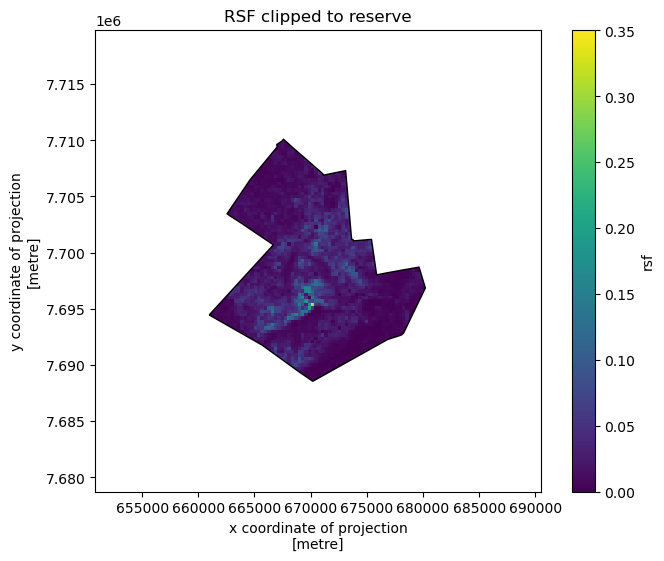

In [108]:
# Clip RSF to reserve
if "band" in rsf.dims:
    rsf2 = rsf.isel(band=0, drop=True)
else:
    rsf2 = rsf

# ensure CRS exists
if rsf2.rio.crs is None:
    rsf2 = rsf2.rio.write_crs(perimeter.crs)

perim = perimeter.to_crs(rsf2.rio.crs)
rsf_clip = rsf2.rio.clip(perim.geometry, perim.crs, drop=False)

fig, ax = plt.subplots(figsize=(8, 6))
rsf_clip.plot(ax=ax)
perim.boundary.plot(ax=ax, color="black", linewidth=1)
ax.set_title("RSF clipped to reserve")
ax.set_aspect("equal")
plt.show()

This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
[1.99813361e-14 5.89782260e-03 1.21108353e-02 2.11018078e-02
 3.72172669e-02 3.50697279e-01]
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.


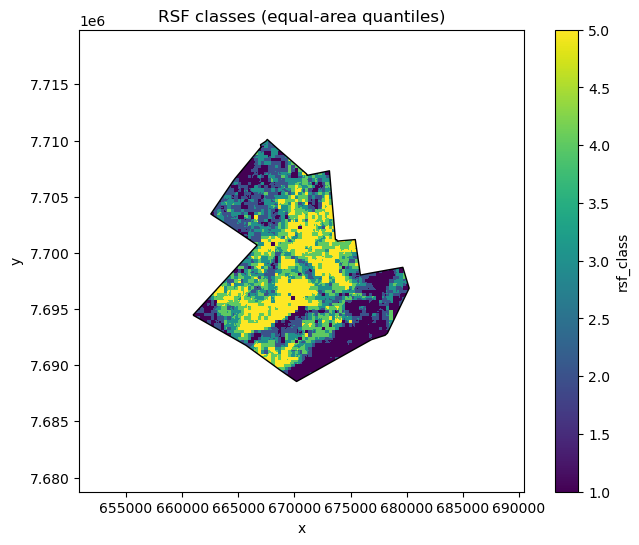

In [111]:
# Find quantiles
vals = rsf_clip.values
vals = vals[np.isfinite(vals)]

q = np.quantile(vals, np.linspace(0, 1, 6))
print(q)

rsf_class = rsf_clip.copy() * np.nan

for i in range(5):
    lo, hi = q[i], q[i + 1]
    if i < 4:
        mask = (rsf_clip >= lo) & (rsf_clip < hi)
    else:
        mask = (rsf_clip >= lo) & (rsf_clip <= hi)
    rsf_class = xr.where(mask, i + 1, rsf_class)

rsf_class = rsf_class.rename("rsf_class")

fig, ax = plt.subplots(figsize=(8, 6))
rsf_class.plot(ax=ax, cmap="viridis")
perim.boundary.plot(ax=ax, color="black", linewidth=1)
ax.set_title("RSF classes (equal-area quantiles)")
ax.set_aspect("equal")
plt.show()

In [112]:
# Check if well distributed
class_counts = (
    pd.Series(rsf_class.values[np.isfinite(rsf_class.values)].astype(int))
    .value_counts()
    .sort_index()
)
class_counts

This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.


1    47777
2    47776
3    47777
4    47776
5    47777
Name: count, dtype: int64

This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/

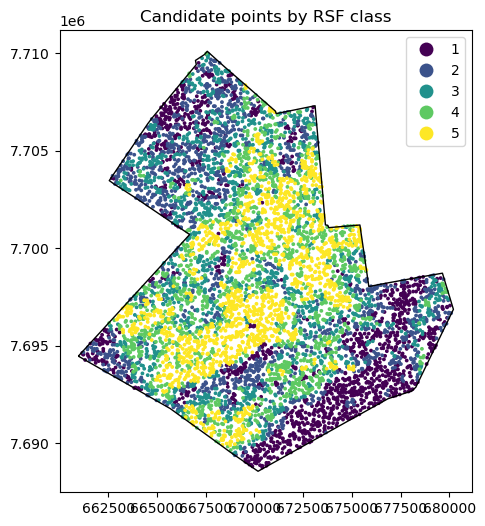

In [114]:
# Generate candidate points
from shapely.geometry import Point

def sample_points_from_class_mask(mask: xr.DataArray, n: int, seed: int):
    yy, xx = np.where(mask.values)
    if len(xx) == 0:
        return gpd.GeoDataFrame(geometry=[], crs=perim.crs)

    rng = np.random.default_rng(seed)
    take = min(n, len(xx))
    idx = rng.choice(len(xx), size=take, replace=False)

    xs = mask["x"].values[xx[idx]]
    ys = mask["y"].values[yy[idx]]

    gdf = gpd.GeoDataFrame(
        {"x": xs, "y": ys},
        geometry=[Point(x, y) for x, y in zip(xs, ys)],
        crs=perim.crs,
    )
    return gdf

candidate_parts = []
for cls in range(1, 6):
    mask = rsf_class == cls
    pts = sample_points_from_class_mask(mask, n=1500, seed=42 + cls)
    pts["rsf_class"] = cls
    candidate_parts.append(pts)

candidates = gpd.GeoDataFrame(
    pd.concat(candidate_parts, ignore_index=True),
    geometry="geometry",
    crs=perim.crs,
)

fig, ax = plt.subplots(figsize=(8, 6))
perim.boundary.plot(ax=ax, color="black", linewidth=1)
candidates.plot(ax=ax, column="rsf_class", categorical=True, cmap = "viridis", markersize=3, legend=True)
ax.set_title("Candidate points by RSF class")
ax.set_aspect("equal")
plt.show()

In [115]:
# Add ecological predictors to candidate points
materialized = materialize_predictors(
    env_dict=env_dict,
    predictor_cols=predictor_cols,
    dtype="float32",
)

cand_df = sample_predictors_materialized(
    samples=candidates,
    materialized=materialized,
    predictor_cols=predictor_cols,
    include_metadata=True,
)

cand_df["rsf_class"] = candidates["rsf_class"].to_numpy()


RSF class 1
PC1    0.452119
PC2    0.142873
PC3    0.128905
dtype: float32

RSF class 2
PC1    0.340241
PC2    0.180570
PC3    0.134231
dtype: float32

RSF class 3
PC1    0.338218
PC2    0.187347
PC3    0.148785
dtype: float32

RSF class 4
PC1    0.318566
PC2    0.201356
PC3    0.142286
dtype: float32

RSF class 5
PC1    0.300800
PC2    0.166936
PC3    0.143372
dtype: float32


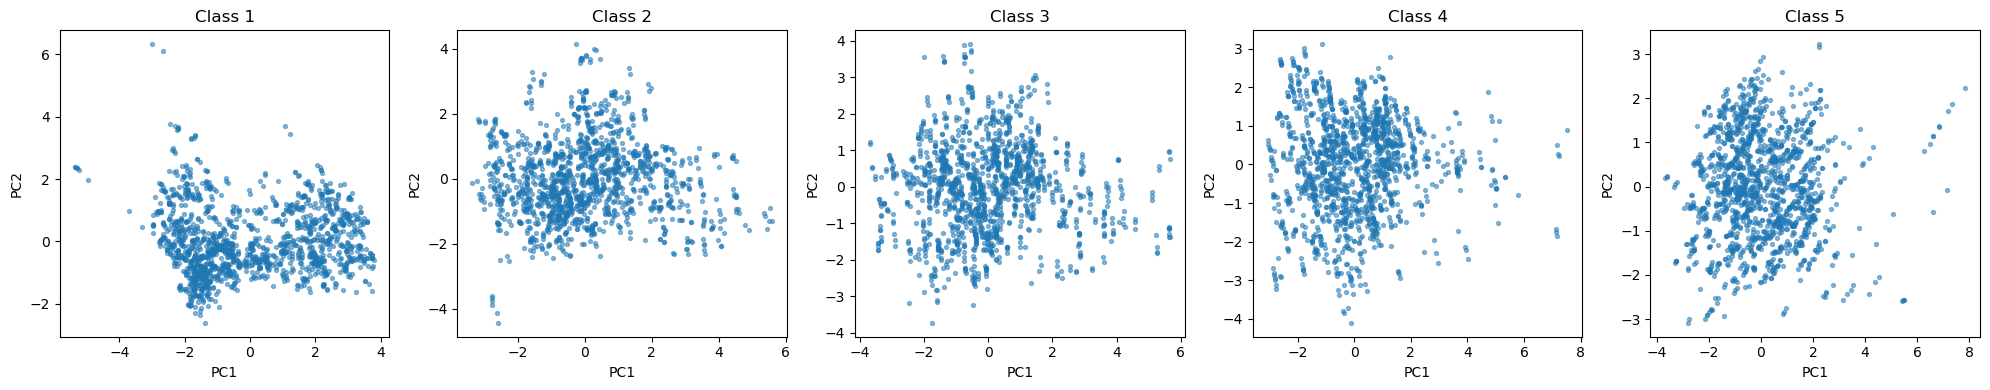

In [ ]:
# Perform PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_results = []
diag = []

for cls in sorted(cand_df["rsf_class"].unique()):
    sub = cand_df[cand_df["rsf_class"] == cls].copy()

    X = sub[predictor_cols].to_numpy()
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    pca = PCA(n_components=min(3, Xs.shape[1]), random_state=42)
    scores = pca.fit_transform(Xs)

    for i in range(scores.shape[1]):
        sub[f"PC{i+1}"] = scores[:, i]

    sub["row_id"] = sub.index
    pca_results.append(sub)

    loadings = pd.DataFrame(
        pca.components_.T,
        index=predictor_cols,
        columns=[f"PC{i+1}" for i in range(scores.shape[1])]
    )

    evr = pd.Series(
        pca.explained_variance_ratio_,
        index=[f"PC{i+1}" for i in range(scores.shape[1])]
    )

    diag.append({
        "rsf_class": cls,
        "loadings": loadings,
        "evr": evr
    })

pca_df = pd.concat(pca_results, ignore_index=True)

for d in diag:
    print(f"\nRSF class {d['rsf_class']}")
    print(d["evr"])

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=False, sharey=False)

for ax, cls in zip(axes, sorted(pca_df["rsf_class"].unique())):
    sub = pca_df[pca_df["rsf_class"] == cls]
    ax.scatter(sub["PC1"], sub["PC2"], s=8, alpha=0.5)
    ax.set_title(f"Class {cls}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

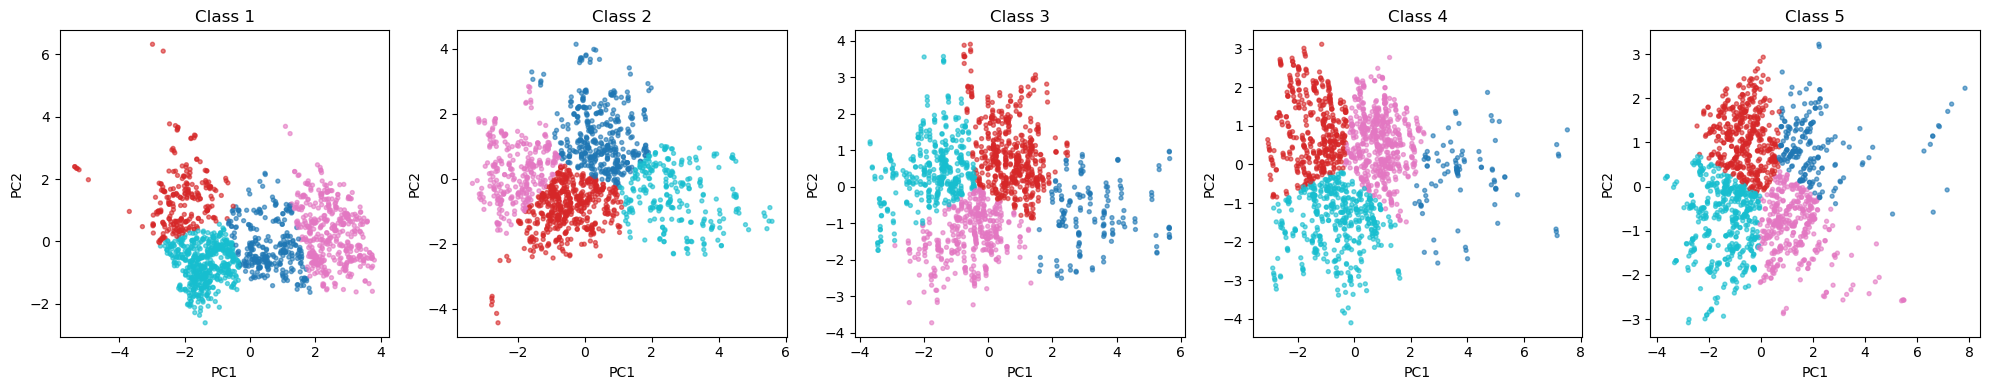

In [ ]:
# Cluster 

from sklearn.cluster import KMeans

clustered_parts = []

for cls in sorted(pca_df["rsf_class"].unique()):
    sub = pca_df[pca_df["rsf_class"] == cls].copy()

    X = sub[["PC1", "PC2"]].to_numpy()
    km = KMeans(n_clusters=4, random_state=42, n_init=20)
    sub["cluster"] = km.fit_predict(X)

    clustered_parts.append(sub)

clustered = pd.concat(clustered_parts, ignore_index=True)

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=False, sharey=False)

for ax, cls in zip(axes, sorted(clustered["rsf_class"].unique())):
    sub = clustered[clustered["rsf_class"] == cls]
    ax.scatter(sub["PC1"], sub["PC2"], c=sub["cluster"], s=8, alpha=0.6, cmap="tab10")
    ax.set_title(f"Class {cls}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

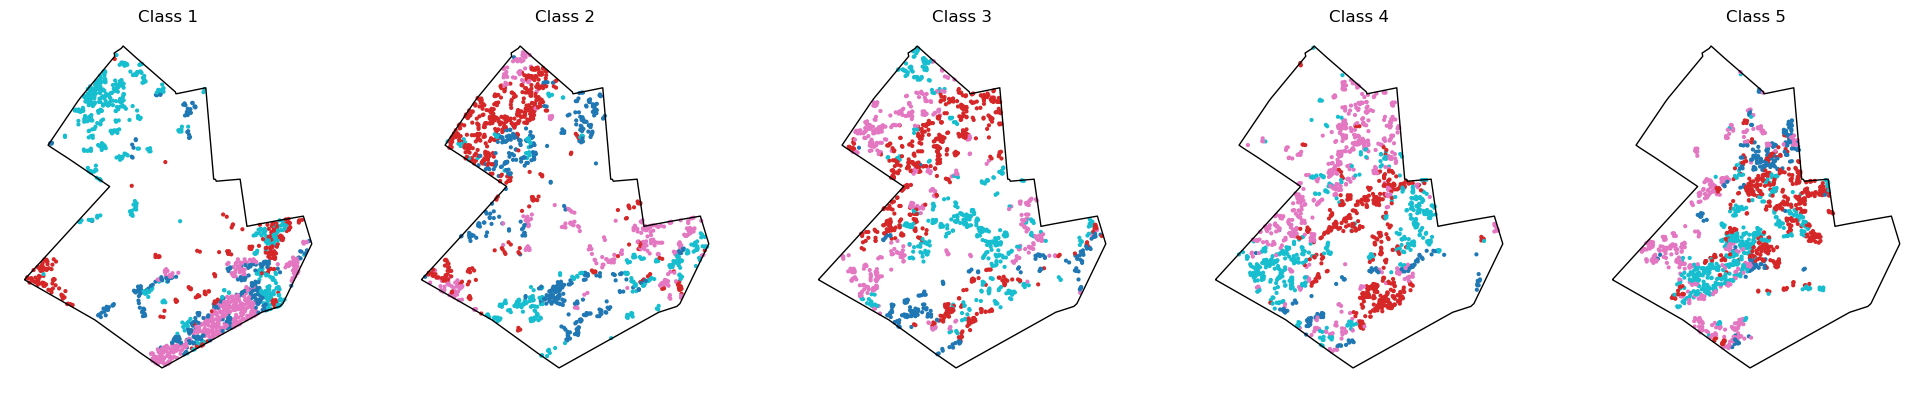

In [118]:
# Plot candidate points according to cluster in space
clustered_gdf = candidates.copy()
clustered_gdf["rsf_class"] = clustered["rsf_class"].to_numpy()
clustered_gdf["cluster"] = clustered["cluster"].to_numpy()

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)

for ax, cls in zip(axes, sorted(clustered_gdf["rsf_class"].unique())):
    perim.boundary.plot(ax=ax, color="black", linewidth=1)
    sub = clustered_gdf[clustered_gdf["rsf_class"] == cls]
    sub.plot(ax=ax, column="cluster", categorical=True, markersize=4, legend=False, cmap="tab10")
    ax.set_title(f"Class {cls}")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [163]:
clustered_gdf.to_file("candidate_points.gpkg")

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skgstat import Variogram

def fit_variogram_for_axis(
    gdf,
    value_col,
    model="spherical",
    n_lags=15,
    maxlag="median",
):
    coords = np.column_stack([gdf.geometry.x.values, gdf.geometry.y.values])
    values = gdf[value_col].values

    ok = np.isfinite(values)
    coords = coords[ok]
    values = values[ok]

    V = Variogram(
        coords,
        values,
        model=model,
        n_lags=n_lags,
        maxlag=maxlag,
        normalize=False,
        use_nugget=True,
    )
    return V

V_pc1 = fit_variogram_for_axis(clustered_gdf.join(clustered[["PC1"]]), "PC1", model = "exponential")
V_pc2 = fit_variogram_for_axis(clustered_gdf.join(clustered[["PC2"]]), "PC2", model = "exponential")

In [142]:
pca_space = clustered_gdf.join(clustered[["PC1", "PC2"]])

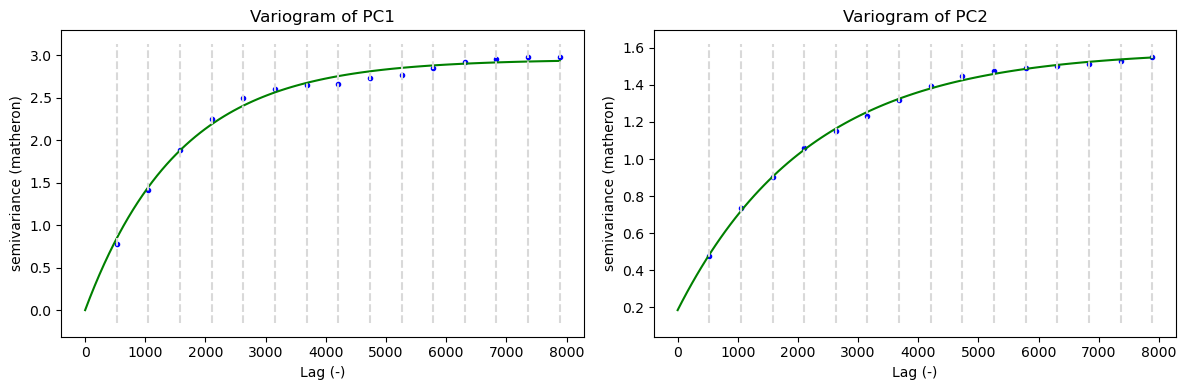

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

V_pc1.plot(axes=axes[0])
axes[0].set_title("Variogram of PC1")

V_pc2.plot(axes=axes[1])
axes[1].set_title("Variogram of PC2")

plt.tight_layout()
plt.show()

In [129]:
range_pc1 = V_pc1.parameters[0]
range_pc2 = V_pc2.parameters[0]

range_pc1 = V_pc1.parameters[0]
range_pc2 = V_pc2.parameters[0]

min_distance_variogram = max(range_pc1, range_pc2)
print(min_distance_variogram)

6566.011492384544


In [148]:
# By rsf class
ranges_by_class = {}

for cls in sorted(pca_space["rsf_class"].unique()):
    sub = pca_space[pca_space["rsf_class"] == cls].copy()

    V1 = fit_variogram_for_axis(sub, "PC1", model = "spherical")
    V2 = fit_variogram_for_axis(sub, "PC2", model = "spherical")

    r1 = V1.parameters[0]
    r2 = V2.parameters[0]

    ranges_by_class[cls] = {
        "range_pc1": r1,
        "range_pc2": r2,
        "min_distance": max(r1, r2),
        "V_pc1": V1,
        "V_pc2": V2,
    }

ranges_by_class

{np.int64(1): {'range_pc1': np.float64(4500.830796865247),
  'range_pc2': np.float64(3942.160785772475),
  'min_distance': np.float64(4500.830796865247),
  'V_pc1': < spherical Semivariogram fitted to 15 bins >,
  'V_pc2': < spherical Semivariogram fitted to 15 bins >},
 np.int64(2): {'range_pc1': np.float64(3851.3437614996783),
  'range_pc2': np.float64(8518.554911285884),
  'min_distance': np.float64(8518.554911285884),
  'V_pc1': < spherical Semivariogram fitted to 15 bins >,
  'V_pc2': < spherical Semivariogram fitted to 15 bins >},
 np.int64(3): {'range_pc1': np.float64(6081.971889599418),
  'range_pc2': np.float64(5386.203145087288),
  'min_distance': np.float64(6081.971889599418),
  'V_pc1': < spherical Semivariogram fitted to 15 bins >,
  'V_pc2': < spherical Semivariogram fitted to 15 bins >},
 np.int64(4): {'range_pc1': np.float64(4907.235693928849),
  'range_pc2': np.float64(6167.950673675155),
  'min_distance': np.float64(6167.950673675155),
  'V_pc1': < spherical Semivario

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 2, figsize=(12, 18))

for i, cls in enumerate(sorted(ranges_by_class.keys())):
    ranges_by_class[cls]["V_pc1"].plot(axes=axes[i, 0])
    axes[i, 0].set_title(f"Class {cls} - PC1")

    ranges_by_class[cls]["V_pc2"].plot(axes=axes[i, 1])
    axes[i, 1].set_title(f"Class {cls} - PC2")

plt.tight_layout()
plt.show()

In [130]:
def select_replicates(sub_gdf, sub_df, min_distance=500, reps_per_cluster=2):
    chosen = []

    for cl in sorted(sub_df["cluster"].unique()):
        sdf = sub_df[sub_df["cluster"] == cl].copy()

        # choose points closest to cluster center in PCA space
        center = sdf[["PC1", "PC2"]].mean().to_numpy()
        d = np.sqrt(((sdf[["PC1", "PC2"]].to_numpy() - center) ** 2).sum(axis=1))
        sdf["dist_to_center"] = d
        sdf = sdf.sort_values("dist_to_center")

        picked_idx = []
        picked_geom = []

        for idx in sdf.index:
            geom = sub_gdf.loc[idx, "geometry"]
            if len(picked_geom) == 0:
                picked_idx.append(idx)
                picked_geom.append(geom)
            else:
                dd = [geom.distance(g) for g in picked_geom]
                if np.min(dd) >= min_distance:
                    picked_idx.append(idx)
                    picked_geom.append(geom)

            if len(picked_idx) >= reps_per_cluster:
                break

        # fallback if spacing too strict
        if len(picked_idx) < reps_per_cluster:
            remaining = [idx for idx in sdf.index if idx not in picked_idx]
            picked_idx.extend(remaining[:(reps_per_cluster - len(picked_idx))])

        chosen.extend(picked_idx[:reps_per_cluster])

    return chosen

In [156]:
selected_idx = []

for cls in sorted(clustered["rsf_class"].unique()):
    sub_df = clustered[clustered["rsf_class"] == cls].copy()
    sub_gdf = clustered_gdf.loc[sub_df.index].copy()

    idx = select_replicates(
        sub_gdf=sub_gdf,
        sub_df=sub_df,
        min_distance=min_distance_variogram,
        reps_per_cluster=2
    )
    selected_idx.extend(idx)

selected_sites = clustered_gdf.loc[selected_idx].copy().reset_index(drop=True)
selected_sites["site_id"] = [f"S{i+1:02d}" for i in range(len(selected_sites))]

In [157]:
selected_sites.groupby(["rsf_class", "cluster"]).size()

rsf_class  cluster
1          0          2
           1          2
           2          2
           3          2
2          0          2
           1          2
           2          2
           3          2
3          0          2
           1          2
           2          2
           3          2
4          0          2
           1          2
           2          2
           3          2
5          0          2
           1          2
           2          2
           3          2
dtype: int64

This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.


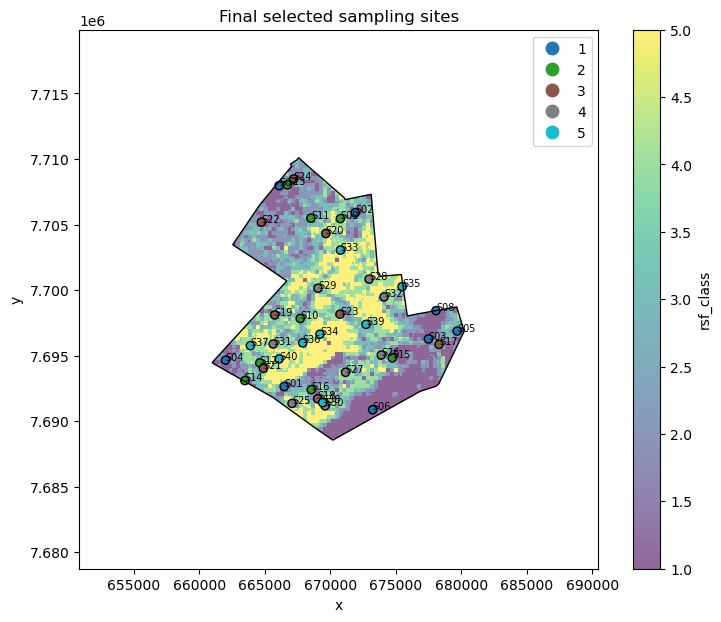

In [158]:
fig, ax = plt.subplots(figsize=(9, 7))
rsf_class.plot(ax=ax, cmap="viridis", alpha=0.6)
perim.boundary.plot(ax=ax, color="black", linewidth=1)
selected_sites.plot(
    ax=ax,
    column="rsf_class",
    categorical=True,
    markersize=35,
    edgecolor="black",
    legend=True
)

for _, row in selected_sites.iterrows():
    ax.text(row.geometry.x, row.geometry.y, row.site_id, fontsize=7)

ax.set_title("Final selected sampling sites")
ax.set_aspect("equal")
plt.show()

In [153]:
from scipy.spatial.distance import pdist

selected_sites["x"] = selected_sites.geometry.x
selected_sites["y"] = selected_sites.geometry.y

spacing_summary = []
for cls in sorted(selected_sites["rsf_class"].unique()):
    for cl in sorted(selected_sites["cluster"].unique()):
        sub = selected_sites[
            (selected_sites["rsf_class"] == cls) &
            (selected_sites["cluster"] == cl)
        ]
        if len(sub) == 2:
            d = pdist(sub[["x", "y"]].to_numpy())[0]
            spacing_summary.append({
                "rsf_class": cls,
                "cluster": cl,
                "distance_m": d
            })

spacing_summary = pd.DataFrame(spacing_summary)
spacing_summary

,rsf_class,cluster,distance_m
0,1,0,6518.289653
1,1,1,15564.536614
2,1,2,8809.228116
3,1,3,15306.616217
4,2,0,11390.917435
5,2,1,11708.612215
6,2,2,15287.288837
7,2,3,9750.000000
8,3,0,10152.462755
9,3,1,7333.082571


In [154]:
selected_env = cand_df.loc[selected_sites.index, predictor_cols + ["rsf_class"]].copy()
selected_env["cluster"] = selected_sites["cluster"].to_numpy()
selected_env["site_id"] = selected_sites["site_id"].to_numpy()

selected_env.head()

,grass_prob_std_90m,elevation_300m,lst_p90_300m,sand_300m,dist2water_30m,ndvi_min_300m,vvvh_cv_30m_300m,ndvi_mean_90m_300m,rsf_class,cluster,site_id
0,0.019961,1557.199951,45.627186,61.450001,1385.207520,0.023914,0.071601,0.288406,1,0,S01
1,0.034960,1566.770020,44.035999,54.740002,3063.233643,-0.019459,0.072053,0.349756,1,0,S02
2,0.027803,1634.209961,48.503891,62.779999,4488.485352,0.041722,0.081059,0.291004,1,1,S03
3,0.020157,1594.109985,48.451332,59.330002,1746.453491,0.019381,0.085408,0.300344,1,1,S04
4,0.100038,1597.160034,41.730961,56.020000,2466.759033,0.056102,0.095848,0.364427,1,2,S05


In [161]:
selected_sites.to_file("selected_sites.gpkg")